# 🧠 RAG Chunking Strategies — Master Notebook

> **Purpose:** A self-contained, runnable evaluation notebook for every major text chunking strategy used in Retrieval-Augmented Generation (RAG) systems.  
> Run this notebook at the start of any RAG project to understand which chunking strategy best fits your use-case.

---

## 📋 Table of Contents
1. [Setup & Sample Corpus](#1-setup)
2. [Fixed-Size Chunking](#2-fixed-size)
3. [Sliding Window Chunking](#3-sliding-window)
4. [Sentence-Based Chunking](#4-sentence)
5. [Paragraph / Section-Based Chunking](#5-paragraph)
6. [Recursive Character Splitting](#6-recursive)
7. [Semantic Chunking (Embedding-Similarity)](#7-semantic)
8. [Document-Structure Chunking (Markdown/HTML)](#8-structure)
9. [Agentic / Proposition-Level Chunking](#9-proposition)
10. [Comparative Visualizations & Impact Analysis](#10-compare)
11. [Decision Framework — When to Use What](#11-framework)
12. [🚀 Wrapper: Quick Evaluation Harness](#12-harness)

---

### ⚡ Quick Start
Run all cells top-to-bottom. The final section (**Section 12**) provides a **plug-and-play wrapper** — paste your own text corpus into `MY_CORPUS` and get an instant evaluation report.


## 1. Setup & Sample Corpus <a id='1-setup'></a>

We import all necessary libraries and define a **realistic, multi-genre sample corpus** that mimics real RAG workloads (technical docs, legal text, narrative prose, FAQ content).

In [1]:
import re
import math
import textwrap
import warnings
import collections
from typing import List, Dict, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import gaussian_kde

warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#3d4166',
    'axes.labelcolor': '#c8cce8',
    'xtick.color': '#8890bb',
    'ytick.color': '#8890bb',
    'text.color': '#e0e3f5',
    'grid.color': '#2a2d47',
    'grid.alpha': 0.6,
    'lines.linewidth': 2,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.framealpha': 0.3,
    'legend.edgecolor': '#3d4166',
})

ACCENT = ['#7c6af7', '#f76a8c', '#4ecdc4', '#ffe66d', '#a8e6cf', '#ff8b94', '#88c0d0']
CMAP   = LinearSegmentedColormap.from_list('rag', ['#1a1d2e', '#7c6af7', '#f76a8c'])

print("✅ Libraries loaded. Style applied.")


✅ Libraries loaded. Style applied.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SAMPLE CORPUS  — change these for your own project (see Section 12)
# ─────────────────────────────────────────────────────────────────────────────

CORPUS = {
    "technical_doc": """
## Introduction to Vector Databases

Vector databases are specialized storage systems designed to handle high-dimensional vector embeddings efficiently. 
Unlike traditional relational databases that store structured tabular data, vector databases index floating-point 
arrays and support similarity searches using metrics such as cosine similarity, Euclidean distance, and dot product.

### How Embeddings Work

An embedding is a dense numerical representation of an object — text, image, audio — in a high-dimensional space.
Semantically similar objects are mapped to nearby points. A sentence-transformer model might produce 768-dimensional 
vectors, while larger models like text-embedding-3-large output 3072 dimensions.

### HNSW Indexing

Hierarchical Navigable Small World (HNSW) is the dominant indexing algorithm for approximate nearest-neighbor (ANN) 
search. It builds a multi-layer graph where each layer is a subset of the previous, enabling logarithmic search 
complexity. The ef_construction parameter controls index build quality, while ef_search governs query-time accuracy.
Increasing these values improves recall at the cost of latency and memory.

### Choosing a Vector Database

When evaluating vector databases, consider: (1) indexing algorithm support (HNSW vs IVF vs flat); 
(2) filtering capabilities — can you combine metadata filters with ANN search?; (3) scalability — does it 
support distributed deployments?; (4) persistence and durability guarantees. Popular options include 
Pinecone, Weaviate, Qdrant, Milvus, and pgvector for PostgreSQL.
""",

    "legal_text": """
TERMS OF SERVICE — EFFECTIVE DATE: JANUARY 1, 2025

1. ACCEPTANCE OF TERMS

By accessing or using the Service, you agree to be bound by these Terms of Service ("Terms"). 
If you do not agree to these Terms, you may not access or use the Service. These Terms constitute 
a legally binding agreement between you ("User") and Acme Corporation ("Company").

2. USER OBLIGATIONS

2.1 Account Security. You are responsible for maintaining the confidentiality of your account 
credentials. You must immediately notify the Company of any unauthorized use of your account.

2.2 Prohibited Conduct. You agree not to: (a) reverse engineer or decompile any portion of the 
Service; (b) use the Service to transmit unsolicited commercial communications; (c) attempt to 
gain unauthorized access to any systems or networks connected to the Service; (d) use automated 
tools to scrape, crawl, or extract data from the Service without prior written consent.

3. INTELLECTUAL PROPERTY

All content, trademarks, service marks, and trade names displayed on the Service are proprietary 
to the Company or its licensors. Nothing in these Terms grants you any right, title, or interest 
in any intellectual property owned or licensed by the Company.

4. LIMITATION OF LIABILITY

TO THE MAXIMUM EXTENT PERMITTED BY APPLICABLE LAW, THE COMPANY SHALL NOT BE LIABLE FOR ANY 
INDIRECT, INCIDENTAL, SPECIAL, CONSEQUENTIAL, OR PUNITIVE DAMAGES. THE COMPANY'S TOTAL LIABILITY 
SHALL NOT EXCEED THE AMOUNTS PAID BY YOU IN THE TWELVE MONTHS PRECEDING THE CLAIM.
""",

    "narrative_prose": """
The morning light filtered through the blinds in thin gold strips, landing across Maya's keyboard 
like a gentle accusation. She had been awake since four, running the numbers again. The simulation 
kept converging on the same answer: forty-three days.

She pushed back from the desk and walked to the window. The city below was already humming — 
delivery trucks threading between yellow cabs, a jogger weaving past a newsstand, steam rising 
in lazy spirals from a grate in the sidewalk. All of it ordinary. All of it borrowed.

The phone buzzed. It was Chen.

"Tell me you found an error," he said without preamble.

"I found three errors," Maya replied. "Fixed them all. The answer didn't change."

A long silence. Then: "What do we do with forty-three days?"

She watched a pigeon settle on the ledge outside, completely unconcerned with planetary timelines.
"We start with what's in front of us," she said. "Same as always."

She turned back to the keyboard. The cursor blinked, patient as a metronome, waiting for her 
to write the next part of the plan that might save everything — or confirm that nothing could.
""",

    "faq_content": """
Q: What is retrieval-augmented generation (RAG)?
A: RAG is an AI framework that combines a retrieval system with a generative language model. Instead of relying solely on parametric knowledge baked into model weights, RAG retrieves relevant documents from an external knowledge base at inference time and provides them as context to the LLM.

Q: Why does chunking matter for RAG?
A: The quality of chunking directly impacts retrieval precision. Chunks that are too large carry irrelevant information and may exceed context windows. Chunks that are too small lose surrounding context needed for comprehension. The optimal chunk size depends on your document type, embedding model, and query patterns.

Q: What chunk size should I start with?
A: A common starting point is 512 tokens with a 64-token overlap for general-purpose RAG. Technical documentation often benefits from larger chunks (1024 tokens) to preserve code blocks and explanations together. Conversational FAQ content works well with smaller chunks (128–256 tokens) since each Q&A pair is self-contained.

Q: Should I always use overlap?
A: Overlap helps preserve context at chunk boundaries and is generally recommended for prose. For structured data (code, tables, Q&A pairs), overlap adds noise and is often counterproductive. Semantic chunking naturally handles boundaries without needing overlap.

Q: How do I evaluate chunking quality?
A: Key metrics include: (1) retrieval recall@k — does the correct chunk appear in top-k results?; (2) faithfulness — does the generated answer reflect only retrieved content?; (3) chunk coherence — is each chunk semantically self-contained?; (4) chunk size distribution — are chunks consistent in size?
"""
}

# Combine all docs into a flat list for multi-doc analysis
ALL_TEXT = "\n\n".join(CORPUS.values())

print(f"📚 Corpus loaded: {len(CORPUS)} documents")
for name, text in CORPUS.items():
    words = len(text.split())
    chars = len(text)
    print(f"  • {name:<20} {words:>5} words  |  {chars:>6} chars")

print(f"\n  Total: {len(ALL_TEXT.split()):,} words  |  {len(ALL_TEXT):,} chars")


📚 Corpus loaded: 4 documents
  • technical_doc          208 words  |    1574 chars
  • legal_text             238 words  |    1531 chars
  • narrative_prose        189 words  |    1122 chars
  • faq_content            257 words  |    1709 chars

  Total: 892 words  |  5,942 chars


## 2. Fixed-Size Chunking <a id='2-fixed-size'></a>

**What it is:** Split text every N characters (or tokens), ignoring all semantic boundaries.

**Pros:** Fast, deterministic, trivially parallelizable, no dependencies.  
**Cons:** Splits mid-sentence, mid-word, mid-concept — poor semantic coherence.  
**Best for:** Quick prototyping, homogeneous structured logs, situations where speed > quality.

> ⚠️ **Gotcha:** Real token counts differ from character counts. At ~4 chars/token (English), a 512-token chunk ≈ 2048 characters.


In [3]:
# ─── Fixed-Size Chunker ───────────────────────────────────────────────────────

def fixed_size_chunker(text: str, chunk_size: int = 500, overlap: int = 0) -> List[Dict]:
    """
    Split text into fixed-size character chunks.

    Args:
        text       : Input text string
        chunk_size : Number of characters per chunk
        overlap    : Characters of overlap between consecutive chunks

    Returns:
        List of dicts with keys: chunk_id, text, start, end, size
    """
    chunks = []
    step = chunk_size - overlap
    if step <= 0:
        raise ValueError("overlap must be less than chunk_size")

    for i, start in enumerate(range(0, len(text), step)):
        end = min(start + chunk_size, len(text))
        chunk_text = text[start:end]
        if chunk_text.strip():  # skip whitespace-only chunks
            chunks.append({
                "chunk_id"  : i,
                "text"      : chunk_text,
                "start"     : start,
                "end"       : end,
                "size"      : len(chunk_text),
                "word_count": len(chunk_text.split()),
            })
        if end == len(text):
            break
    return chunks


# ── Demo ────────────────────────────────────────────────────────────────────
sample = CORPUS["technical_doc"]

configs = [
    {"chunk_size": 200, "overlap": 0,  "label": "size=200, no overlap"},
    {"chunk_size": 500, "overlap": 0,  "label": "size=500, no overlap"},
    {"chunk_size": 500, "overlap": 100,"label": "size=500, overlap=100"},
    {"chunk_size": 1000,"overlap": 200,"label": "size=1000, overlap=200"},
]

print("📏 Fixed-Size Chunking Results\n" + "="*60)
for cfg in configs:
    chunks = fixed_size_chunker(sample, cfg["chunk_size"], cfg["overlap"])
    sizes  = [c["size"] for c in chunks]
    print(f"\n  Config: {cfg['label']}")
    print(f"    Chunks produced : {len(chunks)}")
    print(f"    Avg chunk size  : {np.mean(sizes):.0f} chars")
    print(f"    Size std-dev    : {np.std(sizes):.0f} chars")
    print(f"    First chunk preview:")
    print(f"    '{chunks[0]['text'][:120].strip()}...'")

# Boundary problem demonstration
print("\n\n⚠️  BOUNDARY PROBLEM DEMO")
print("-"*60)
boundary_chunks = fixed_size_chunker(sample, 250, 0)
for c in boundary_chunks[:3]:
    last_words = c["text"][-50:].strip()
    first_words = (boundary_chunks[boundary_chunks.index(c)+1]["text"][:50].strip() 
                   if boundary_chunks.index(c)+1 < len(boundary_chunks) else "")
    print(f"  Chunk {c['chunk_id']} ends   : '...{last_words}'")
    if first_words:
        print(f"  Chunk {c['chunk_id']+1} starts : '{first_words}...'")
    print()


📏 Fixed-Size Chunking Results

  Config: size=200, no overlap
    Chunks produced : 8
    Avg chunk size  : 197 chars
    Size std-dev    : 9 chars
    First chunk preview:
    '## Introduction to Vector Databases

Vector databases are specialized storage systems designed to handle high-dimension...'

  Config: size=500, no overlap
    Chunks produced : 4
    Avg chunk size  : 394 chars
    Size std-dev    : 184 chars
    First chunk preview:
    '## Introduction to Vector Databases

Vector databases are specialized storage systems designed to handle high-dimension...'

  Config: size=500, overlap=100
    Chunks produced : 4
    Avg chunk size  : 468 chars
    Size std-dev    : 55 chars
    First chunk preview:
    '## Introduction to Vector Databases

Vector databases are specialized storage systems designed to handle high-dimension...'

  Config: size=1000, overlap=200
    Chunks produced : 2
    Avg chunk size  : 887 chars
    Size std-dev    : 113 chars
    First chunk preview:
   

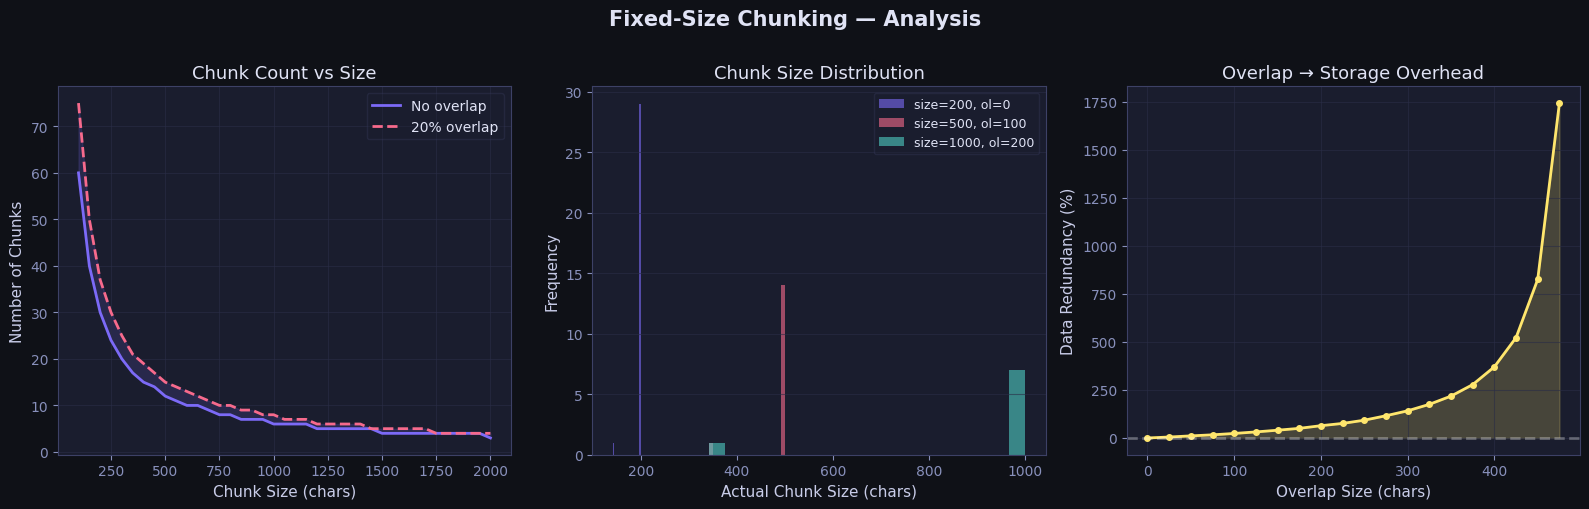

✅ Fixed-size analysis complete


In [5]:
# ─── Visualization: Fixed-Size Chunk Distribution ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fixed-Size Chunking — Analysis", fontsize=15, fontweight='bold', y=1.01)

# Panel 1: chunk count vs size
chunk_sizes_range = range(100, 2001, 50)
counts_no_overlap = [len(fixed_size_chunker(ALL_TEXT, s, 0)) for s in chunk_sizes_range]
counts_20pct      = [len(fixed_size_chunker(ALL_TEXT, s, s//5)) for s in chunk_sizes_range]

ax = axes[0]
ax.plot(chunk_sizes_range, counts_no_overlap, color=ACCENT[0], label='No overlap')
ax.plot(chunk_sizes_range, counts_20pct,      color=ACCENT[1], label='20% overlap', linestyle='--')
ax.fill_between(chunk_sizes_range, counts_no_overlap, counts_20pct, alpha=0.15, color=ACCENT[0])
ax.set_xlabel("Chunk Size (chars)")
ax.set_ylabel("Number of Chunks")
ax.set_title("Chunk Count vs Size")
ax.legend()
ax.grid(True)

# Panel 2: size distribution for a specific config
ax = axes[1]
for i, (sz, ol) in enumerate([(200, 0), (500, 100), (1000, 200)]):
    chunks = fixed_size_chunker(ALL_TEXT, sz, ol)
    sizes  = [c["size"] for c in chunks]
    ax.hist(sizes, bins=20, alpha=0.6, color=ACCENT[i], label=f'size={sz}, ol={ol}', edgecolor='none')
ax.set_xlabel("Actual Chunk Size (chars)")
ax.set_ylabel("Frequency")
ax.set_title("Chunk Size Distribution")
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# Panel 3: overlap impact — information redundancy
ax = axes[2]
overlaps = range(0, 500, 25)
redundancy = []
for ol in overlaps:
    c = fixed_size_chunker(ALL_TEXT, 500, ol)
    total_chars = sum(x["size"] for x in c)
    base_chars  = len(ALL_TEXT)
    redundancy.append((total_chars / base_chars - 1) * 100)

ax.plot(list(overlaps), redundancy, color=ACCENT[3], marker='o', markersize=4)
ax.fill_between(list(overlaps), redundancy, alpha=0.2, color=ACCENT[3])
ax.set_xlabel("Overlap Size (chars)")
ax.set_ylabel("Data Redundancy (%)")
ax.set_title("Overlap → Storage Overhead")
ax.axhline(y=0, color='white', alpha=0.3, linestyle='--')
ax.grid(True)

plt.tight_layout()
plt.show()
print("✅ Fixed-size analysis complete")


## 3. Sliding Window Chunking <a id='3-sliding-window'></a>

**What it is:** A refinement of fixed-size chunking where each chunk advances by a *stride* smaller than the chunk size, creating overlapping windows of context.

**Pros:** Better context continuity at boundaries, good recall for queries spanning chunk borders.  
**Cons:** High storage redundancy, increased embedding cost, duplicate content in retrieval results.  
**Best for:** Dense technical text, legal documents, or any corpus where boundary-crossing queries are common.


In [7]:
# ─── Sliding Window Chunker ──────────────────────────────────────────────────

def sliding_window_chunker(text: str, window_size: int = 500, 
                           stride: int = 250) -> List[Dict]:
    """
    Sliding window with configurable stride.

    Args:
        text        : Input text
        window_size : Characters per chunk
        stride      : How many characters to advance each step (< window_size for overlap)

    Returns:
        List of chunk dicts with coverage metadata
    """
    if stride <= 0:
        raise ValueError("stride must be a positive integer")
    if stride >= window_size:
        # stride == window_size means no overlap — behaves like fixed-size chunker
        stride = window_size
    
    chunks = []
    position = 0
    chunk_id = 0

    while position < len(text):
        end = min(position + window_size, len(text))
        chunk_text = text[position:end]
        if chunk_text.strip():
            overlap_left  = min(window_size - stride, position)
            overlap_right = window_size - stride if end < len(text) else 0
            chunks.append({
                "chunk_id"    : chunk_id,
                "text"        : chunk_text,
                "start"       : position,
                "end"         : end,
                "size"        : len(chunk_text),
                "word_count"  : len(chunk_text.split()),
                "overlap_left": overlap_left,
                "stride"      : stride,
            })
        position += stride
        chunk_id += 1
        if end == len(text):
            break
    return chunks


# ── Stride analysis ─────────────────────────────────────────────────────────
print("🪟 Sliding Window Analysis\n" + "="*60)
window = 600
for stride_pct in [0.25, 0.5, 0.75, 1.0]:
    stride = int(window * stride_pct)
    # stride_pct=1.0 → no overlap (behaves like fixed-size); function handles this gracefully
    chunks = sliding_window_chunker(ALL_TEXT, window, max(stride, 1))
    coverage = (len(chunks) * window) / len(ALL_TEXT)
    print(f"  Stride {stride_pct*100:>3.0f}% ({stride:>3} chars) → "
          f"{len(chunks):>4} chunks  |  "
          f"coverage ratio: {coverage:.2f}x  |  "
          f"overhead: {(coverage-1)*100:.0f}%")

🪟 Sliding Window Analysis
  Stride  25% (150 chars) →   37 chunks  |  coverage ratio: 3.74x  |  overhead: 274%
  Stride  50% (300 chars) →   19 chunks  |  coverage ratio: 1.92x  |  overhead: 92%
  Stride  75% (450 chars) →   13 chunks  |  coverage ratio: 1.31x  |  overhead: 31%
  Stride 100% (600 chars) →   10 chunks  |  coverage ratio: 1.01x  |  overhead: 1%


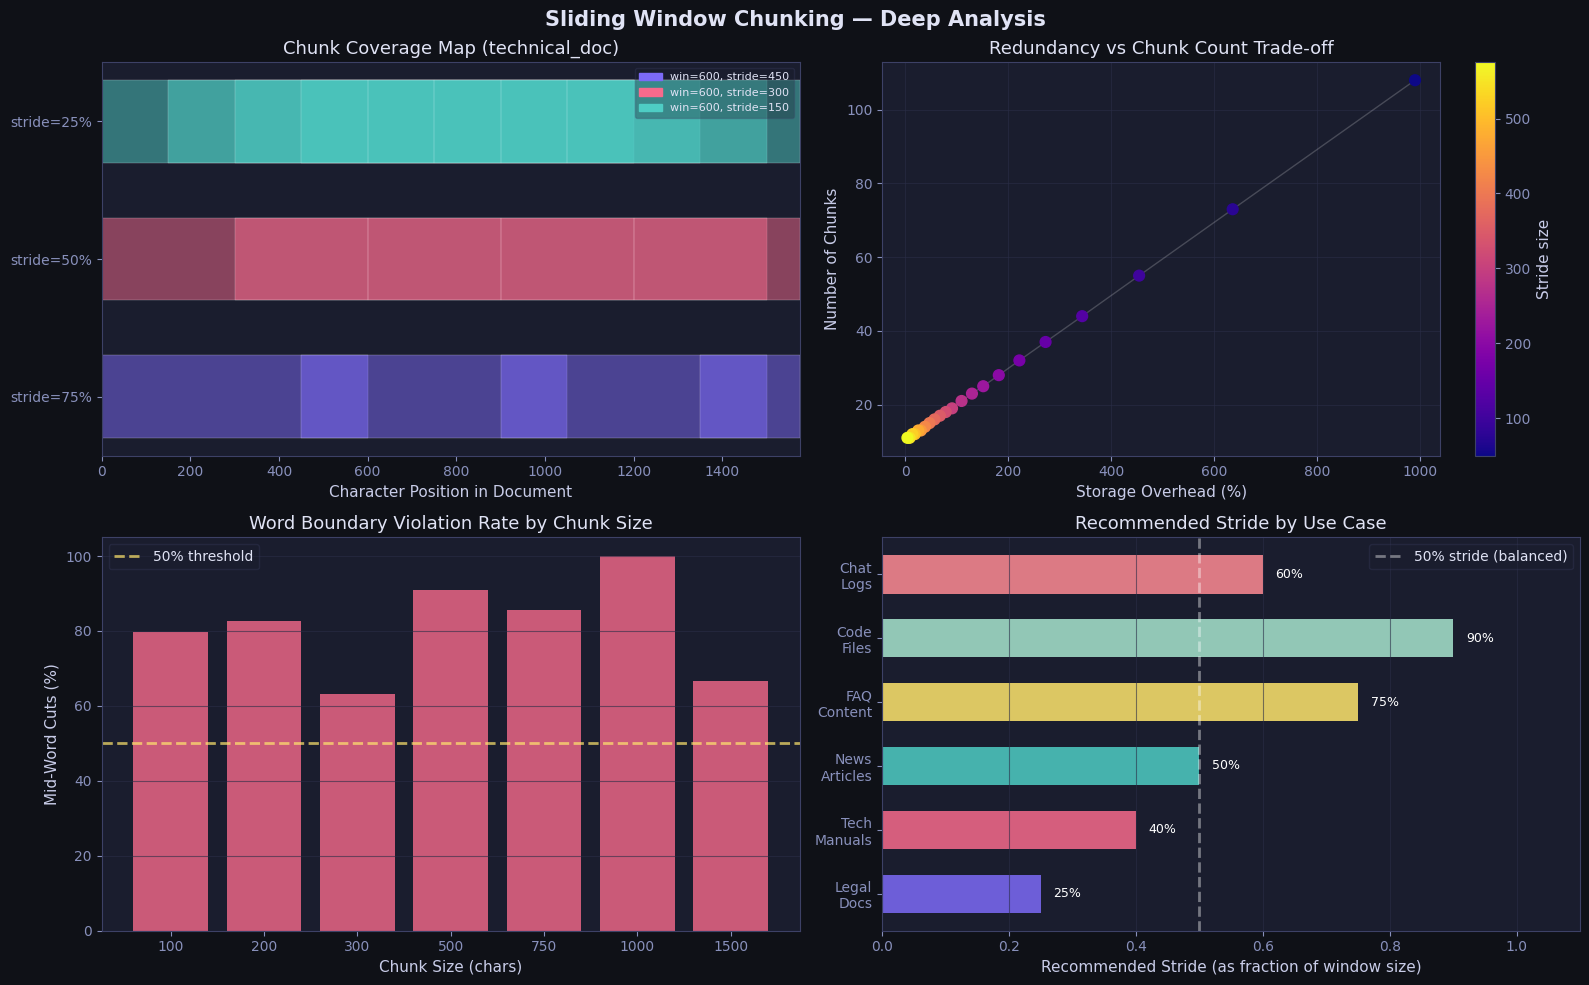

✅ Sliding window analysis complete


In [9]:
# ─── Visualization: Sliding Window Coverage Map ──────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sliding Window Chunking — Deep Analysis", fontsize=15, fontweight='bold')

sample_text = CORPUS["technical_doc"]
text_len = len(sample_text)

# Panel 1: Visual chunk coverage map
ax = axes[0, 0]
configs_sw = [(600, 450, ACCENT[0]), (600, 300, ACCENT[1]), (600, 150, ACCENT[2])]
for row_idx, (win, stride, color) in enumerate(configs_sw):
    chunks = sliding_window_chunker(sample_text, win, stride)
    for c in chunks:
        ax.barh(row_idx, c["end"] - c["start"], left=c["start"], 
                height=0.6, alpha=0.5, color=color, edgecolor='white', linewidth=0.3)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['stride=75%', 'stride=50%', 'stride=25%'])
ax.set_xlabel("Character Position in Document")
ax.set_title("Chunk Coverage Map (technical_doc)")
ax.set_xlim(0, text_len)

# Add legend
patches = [mpatches.Patch(color=c, label=f'win={w}, stride={s}') 
           for w,s,c in configs_sw]
ax.legend(handles=patches, fontsize=8, loc='upper right')

# Panel 2: Redundancy vs Recall trade-off curve
ax = axes[0, 1]
strides = range(50, 601, 25)
redundancies, chunk_counts = [], []
for s in strides:
    if s >= 600: continue
    ch = sliding_window_chunker(ALL_TEXT, 600, s)
    redundancies.append((sum(c["size"] for c in ch) / len(ALL_TEXT) - 1) * 100)
    chunk_counts.append(len(ch))

strides_list = [s for s in strides if s < 600]
sc = ax.scatter(redundancies, chunk_counts, c=strides_list, cmap='plasma', 
                s=60, zorder=5)
ax.plot(redundancies, chunk_counts, color='white', alpha=0.2, linewidth=1)
plt.colorbar(sc, ax=ax, label='Stride size')
ax.set_xlabel("Storage Overhead (%)")
ax.set_ylabel("Number of Chunks")
ax.set_title("Redundancy vs Chunk Count Trade-off")
ax.grid(True)

# Panel 3: Word boundary preservation analysis
ax = axes[1, 0]
def boundary_cuts(text, chunks):
    """Count how many chunks cut in the middle of a word."""
    mid_cuts = 0
    for c in chunks[:-1]:
        last_char = c["text"][-1]
        if last_char not in ' \n\t.,;:!?':
            mid_cuts += 1
    return mid_cuts / max(len(chunks)-1, 1) * 100

chunk_sizes_test = [100, 200, 300, 500, 750, 1000, 1500]
mid_cut_rates = []
for sz in chunk_sizes_test:
    ch = fixed_size_chunker(ALL_TEXT, sz, 0)
    mid_cut_rates.append(boundary_cuts(ALL_TEXT, ch))

ax.bar(range(len(chunk_sizes_test)), mid_cut_rates, color=ACCENT[1], alpha=0.8)
ax.set_xticks(range(len(chunk_sizes_test)))
ax.set_xticklabels([str(s) for s in chunk_sizes_test])
ax.set_xlabel("Chunk Size (chars)")
ax.set_ylabel("Mid-Word Cuts (%)")
ax.set_title("Word Boundary Violation Rate by Chunk Size")
ax.axhline(y=50, color=ACCENT[3], linestyle='--', alpha=0.7, label='50% threshold')
ax.legend()
ax.grid(True, axis='y')

# Panel 4: Optimal stride recommendation chart
ax = axes[1, 1]
use_cases = ['Legal\nDocs', 'Tech\nManuals', 'News\nArticles', 'FAQ\nContent', 'Code\nFiles', 'Chat\nLogs']
recommended_strides = [0.25, 0.40, 0.50, 0.75, 0.90, 0.60]  # as fraction of window
colors_uc = [ACCENT[i % len(ACCENT)] for i in range(len(use_cases))]

bars = ax.barh(use_cases, recommended_strides, color=colors_uc, alpha=0.85, height=0.6)
ax.set_xlabel("Recommended Stride (as fraction of window size)")
ax.set_title("Recommended Stride by Use Case")
ax.set_xlim(0, 1.1)
ax.axvline(x=0.5, color='white', linestyle='--', alpha=0.4, label='50% stride (balanced)')
for bar, val in zip(bars, recommended_strides):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{val*100:.0f}%', va='center', fontsize=9, color='white')
ax.legend()
ax.grid(True, axis='x')

plt.tight_layout()
plt.show()
print("✅ Sliding window analysis complete")


## 4. Sentence-Based Chunking <a id='4-sentence'></a>

**What it is:** Split at sentence boundaries, then group N sentences into each chunk. Uses regex or NLP rules to detect sentence ends.

**Pros:** Chunks are always semantically complete sentences; no mid-sentence splits; natural reading units.  
**Cons:** Sentence length varies wildly → unpredictable chunk sizes; abbreviations (e.g., "Dr.", "U.S.") cause false splits without proper NLP.  
**Best for:** News articles, prose, FAQ answers, chatbot training data, any content with clear sentence structure.


In [10]:
# ─── Sentence-Based Chunker ──────────────────────────────────────────────────

def sentence_splitter(text: str) -> List[str]:
    """
    Rule-based sentence splitter (no external NLP deps).
    Handles common abbreviations to reduce false splits.
    """
    # Protect common abbreviations
    abbrevs = ['Mr', 'Mrs', 'Ms', 'Dr', 'Prof', 'Sr', 'Jr', 'vs', 
                'etc', 'i.e', 'e.g', 'U.S', 'U.K', 'Fig', 'No', 'Vol']
    protected = text
    for abbr in abbrevs:
        protected = re.sub(rf'\b{abbr}\.', abbr.replace('.', '<<<DOT>>>'), protected)
    
    # Split on sentence-ending punctuation followed by space+capital or newline
    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z0-9\"\'])|(?<=[.!?])\n+', protected)
    
    # Restore abbreviations and clean up
    sentences = [s.replace('<<<DOT>>>', '.').strip() for s in sentences if s.strip()]
    return sentences


def sentence_chunker(text: str, sentences_per_chunk: int = 3, 
                     overlap_sentences: int = 1) -> List[Dict]:
    """
    Group N sentences per chunk with optional sentence-level overlap.

    Args:
        text               : Input text
        sentences_per_chunk: How many sentences per chunk
        overlap_sentences  : Sentences shared with the previous chunk

    Returns:
        List of chunk dicts with sentence metadata
    """
    sentences = sentence_splitter(text)
    if not sentences:
        return []

    chunks = []
    step = max(sentences_per_chunk - overlap_sentences, 1)
    chunk_id = 0

    for i in range(0, len(sentences), step):
        sentence_group = sentences[i: i + sentences_per_chunk]
        if not sentence_group:
            continue
        chunk_text = ' '.join(sentence_group)
        chunks.append({
            "chunk_id"       : chunk_id,
            "text"           : chunk_text,
            "size"           : len(chunk_text),
            "word_count"     : len(chunk_text.split()),
            "sentence_count" : len(sentence_group),
            "start_sentence" : i,
            "end_sentence"   : i + len(sentence_group) - 1,
        })
        chunk_id += 1
        if i + sentences_per_chunk >= len(sentences):
            break
    return chunks


# ── Demo ─────────────────────────────────────────────────────────────────────
print("📝 Sentence-Based Chunking Demo\n" + "="*60)
for doc_name, doc_text in CORPUS.items():
    sentences = sentence_splitter(doc_text)
    print(f"\n  Document: {doc_name}")
    print(f"    Detected sentences : {len(sentences)}")
    print(f"    Avg sentence length: {np.mean([len(s) for s in sentences]):.0f} chars")
    print(f"    Sentence std-dev   : {np.std([len(s) for s in sentences]):.0f} chars")
    
    chunks = sentence_chunker(doc_text, sentences_per_chunk=3, overlap_sentences=1)
    print(f"    Chunks (3-sent, ol=1): {len(chunks)}")

print("\n\n  Sample chunk (technical_doc, 3 sentences, 1 overlap):")
print("  " + "─"*56)
demo_chunks = sentence_chunker(CORPUS["technical_doc"], 3, 1)
for c in demo_chunks[:3]:
    print(f"  [Chunk {c['chunk_id']}] {c['sentence_count']} sentences | {c['word_count']} words")
    print(f"  {c['text'][:150]}...")
    print()


📝 Sentence-Based Chunking Demo

  Document: technical_doc
    Detected sentences : 11
    Avg sentence length: 142 chars
    Sentence std-dev   : 70 chars
    Chunks (3-sent, ol=1): 5

  Document: legal_text
    Detected sentences : 16
    Avg sentence length: 94 chars
    Sentence std-dev   : 85 chars
    Chunks (3-sent, ol=1): 8

  Document: narrative_prose
    Detected sentences : 17
    Avg sentence length: 65 chars
    Sentence std-dev   : 51 chars
    Chunks (3-sent, ol=1): 8

  Document: faq_content
    Detected sentences : 18
    Avg sentence length: 94 chars
    Sentence std-dev   : 64 chars
    Chunks (3-sent, ol=1): 9


  Sample chunk (technical_doc, 3 sentences, 1 overlap):
  ────────────────────────────────────────────────────────
  [Chunk 0] 3 sentences | 70 words
  ## Introduction to Vector Databases

Vector databases are specialized storage systems designed to handle high-dimensional vector embeddings efficientl...

  [Chunk 1] 3 sentences | 46 words
  ### How Embedding

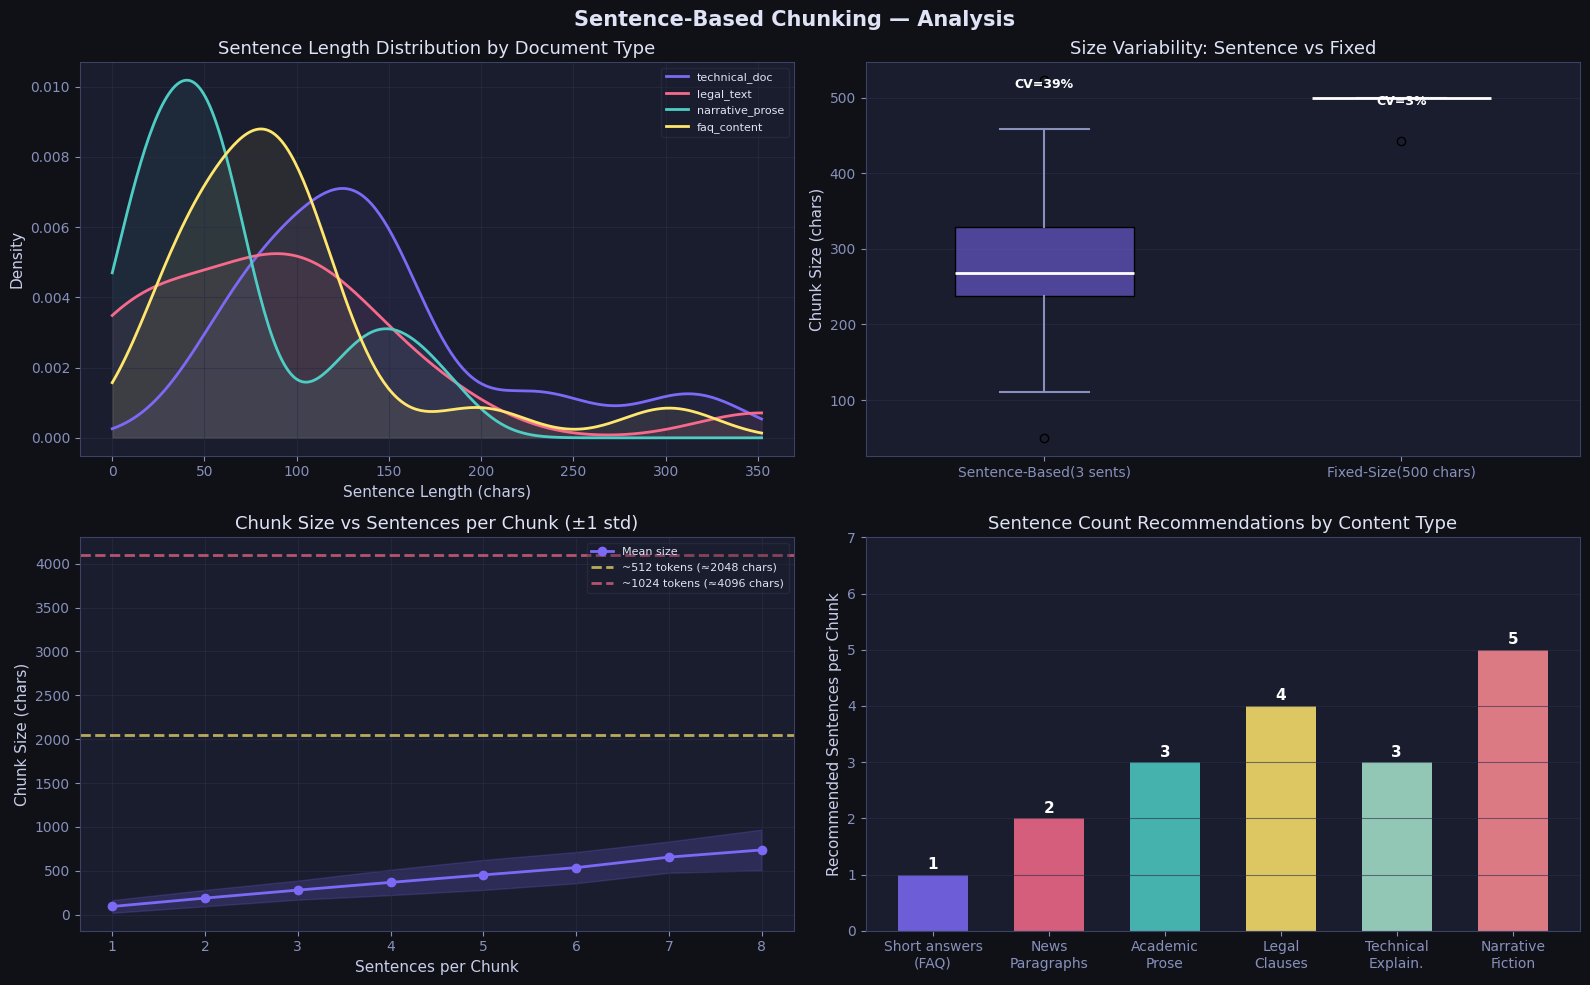

✅ Sentence chunking analysis complete


In [11]:
# ─── Visualization: Sentence Chunking Analysis ───────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sentence-Based Chunking — Analysis", fontsize=15, fontweight='bold')

# Panel 1: Sentence length distribution across corpus
ax = axes[0, 0]
all_sentence_lens = []
doc_sentence_lens = {}
for name, text in CORPUS.items():
    sents = sentence_splitter(text)
    lens  = [len(s) for s in sents]
    doc_sentence_lens[name] = lens
    all_sentence_lens.extend(lens)

for i, (name, lens) in enumerate(doc_sentence_lens.items()):
    if len(lens) > 1:
        kde = gaussian_kde(lens, bw_method=0.4)
        x   = np.linspace(0, max(all_sentence_lens), 300)
        ax.plot(x, kde(x), color=ACCENT[i], label=name, linewidth=2)
        ax.fill_between(x, kde(x), alpha=0.08, color=ACCENT[i])

ax.set_xlabel("Sentence Length (chars)")
ax.set_ylabel("Density")
ax.set_title("Sentence Length Distribution by Document Type")
ax.legend(fontsize=8)
ax.grid(True)

# Panel 2: Chunk size variability (sentences vs fixed)
ax = axes[0, 1]
sent_chunk_sizes = [c["size"] for c in sentence_chunker(ALL_TEXT, 3, 0)]
fixed_chunk_sizes = [c["size"] for c in fixed_size_chunker(ALL_TEXT, 500, 0)]

data_plot = [sent_chunk_sizes, fixed_chunk_sizes]
bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(ACCENT[0] + '88')
bp['boxes'][1].set_facecolor(ACCENT[1] + '88')
for whisker in bp['whiskers']:
    whisker.set(color='#8890bb', linewidth=1.5)
for cap in bp['caps']:
    cap.set(color='#8890bb', linewidth=1.5)

ax.set_xticklabels(['Sentence-Based(3 sents)', 'Fixed-Size(500 chars)'])
ax.set_ylabel("Chunk Size (chars)")
ax.set_title("Size Variability: Sentence vs Fixed")
ax.grid(True, axis='y')

# Add CV annotation
for i, data in enumerate(data_plot, 1):
    cv = np.std(data) / np.mean(data) * 100
    ax.text(i, max(data) * 0.98, f'CV={cv:.0f}%', ha='center', 
            fontsize=9, color='white', fontweight='bold')

# Panel 3: Effect of sentences_per_chunk on chunk sizes
ax = axes[1, 0]
spc_values = [1, 2, 3, 4, 5, 6, 7, 8]
means, stds = [], []
for spc in spc_values:
    ch = sentence_chunker(ALL_TEXT, spc, 0)
    sizes = [c["size"] for c in ch]
    means.append(np.mean(sizes))
    stds.append(np.std(sizes))

means, stds = np.array(means), np.array(stds)
ax.plot(spc_values, means, color=ACCENT[0], marker='o', linewidth=2, label='Mean size')
ax.fill_between(spc_values, means - stds, means + stds, alpha=0.2, color=ACCENT[0])
ax.axhline(y=512*4, color=ACCENT[3], linestyle='--', alpha=0.7, label='~512 tokens (≈2048 chars)')
ax.axhline(y=1024*4, color=ACCENT[1], linestyle='--', alpha=0.7, label='~1024 tokens (≈4096 chars)')
ax.set_xlabel("Sentences per Chunk")
ax.set_ylabel("Chunk Size (chars)")
ax.set_title("Chunk Size vs Sentences per Chunk (±1 std)")
ax.legend(fontsize=8)
ax.grid(True)

# Panel 4: Sentences per chunk recommendation
ax = axes[1, 1]
categories = ['Short answers\n(FAQ)', 'News\nParagraphs', 'Academic\nProse', 
              'Legal\nClauses', 'Technical\nExplain.', 'Narrative\nFiction']
recommended = [1, 2, 3, 4, 3, 5]
colors_bar = [ACCENT[i % len(ACCENT)] for i in range(len(categories))]

bars = ax.bar(categories, recommended, color=colors_bar, alpha=0.85, width=0.6)
ax.set_ylabel("Recommended Sentences per Chunk")
ax.set_title("Sentence Count Recommendations by Content Type")
ax.set_ylim(0, 7)
for bar, val in zip(bars, recommended):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, str(val), 
            ha='center', fontsize=11, fontweight='bold', color='white')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()
print("✅ Sentence chunking analysis complete")


## 5. Paragraph / Section-Based Chunking <a id='5-paragraph'></a>

**What it is:** Use natural paragraph breaks (`\n\n`) or explicit section headers as chunk boundaries. The document's own structure defines chunks.

**Pros:** Highest semantic coherence — paragraphs are already written as self-contained ideas. Respects author intent.  
**Cons:** Highly variable chunk sizes; long paragraphs may exceed embedding context windows; very short paragraphs produce tiny, low-information chunks.  
**Best for:** Markdown docs, articles, Wikipedia-style content, any well-structured prose with clear paragraph breaks.


In [12]:
# ─── Paragraph / Section Chunker ────────────────────────────────────────────

def paragraph_chunker(text: str, min_chars: int = 100, 
                      max_chars: int = 2000,
                      merge_short: bool = True) -> List[Dict]:
    """
    Split on paragraph boundaries (double newlines or section headers).
    Optionally merge short paragraphs and split overly long ones.

    Args:
        text       : Input text
        min_chars  : Paragraphs shorter than this get merged with the next
        max_chars  : Paragraphs longer than this get split at sentence boundaries
        merge_short: Whether to merge short paragraphs

    Returns:
        List of chunk dicts with paragraph metadata
    """
    # Split on double newlines (paragraph markers)
    raw_paras = re.split(r'\n{2,}', text)
    raw_paras = [p.strip() for p in raw_paras if p.strip()]

    # Merge short paragraphs with the next one
    if merge_short:
        merged = []
        buffer = ""
        for para in raw_paras:
            if len(buffer) + len(para) < min_chars and merged:
                buffer += " " + para
            else:
                if buffer:
                    merged.append(buffer)
                buffer = para
        if buffer:
            merged.append(buffer)
        raw_paras = merged

    # Split paragraphs that exceed max_chars at sentence boundaries
    final_paras = []
    for para in raw_paras:
        if len(para) <= max_chars:
            final_paras.append(para)
        else:
            sentences = sentence_splitter(para)
            current   = ""
            for sent in sentences:
                if len(current) + len(sent) <= max_chars:
                    current += (" " if current else "") + sent
                else:
                    if current:
                        final_paras.append(current)
                    current = sent
            if current:
                final_paras.append(current)

    chunks = []
    for i, para in enumerate(final_paras):
        # Detect if this paragraph is a header
        is_header = bool(re.match(r'^#{1,6}\s|^[A-Z][A-Z\s]{5,}$|^\d+\.\s[A-Z]', para))
        chunks.append({
            "chunk_id"  : i,
            "text"      : para,
            "size"      : len(para),
            "word_count": len(para.split()),
            "is_header" : is_header,
            "para_type" : "header" if is_header else "body",
        })
    return chunks


# ── Demo ─────────────────────────────────────────────────────────────────────
print("📄 Paragraph Chunking Demo\n" + "="*60)
for doc_name, doc_text in CORPUS.items():
    chunks = paragraph_chunker(doc_text, min_chars=80, max_chars=1500)
    sizes  = [c["size"] for c in chunks]
    headers = sum(1 for c in chunks if c["is_header"])
    print(f"\n  {doc_name}:")
    print(f"    Paragraphs / chunks : {len(chunks)}")
    print(f"    Header chunks       : {headers}")
    print(f"    Size range          : {min(sizes)} – {max(sizes)} chars")
    print(f"    Mean / Std          : {np.mean(sizes):.0f} / {np.std(sizes):.0f}")


📄 Paragraph Chunking Demo

  technical_doc:
    Paragraphs / chunks : 8
    Header chunks       : 4
    Size range          : 17 – 421 chars
    Mean / Std          : 195 / 171

  legal_text:
    Paragraphs / chunks : 10
    Header chunks       : 4
    Size range          : 19 – 376 chars
    Mean / Std          : 151 / 130

  narrative_prose:
    Paragraphs / chunks : 8
    Header chunks       : 0
    Size range          : 30 – 275 chars
    Mean / Std          : 138 / 89

  faq_content:
    Paragraphs / chunks : 5
    Header chunks       : 0
    Size range          : 295 – 366 chars
    Mean / Std          : 340 / 24


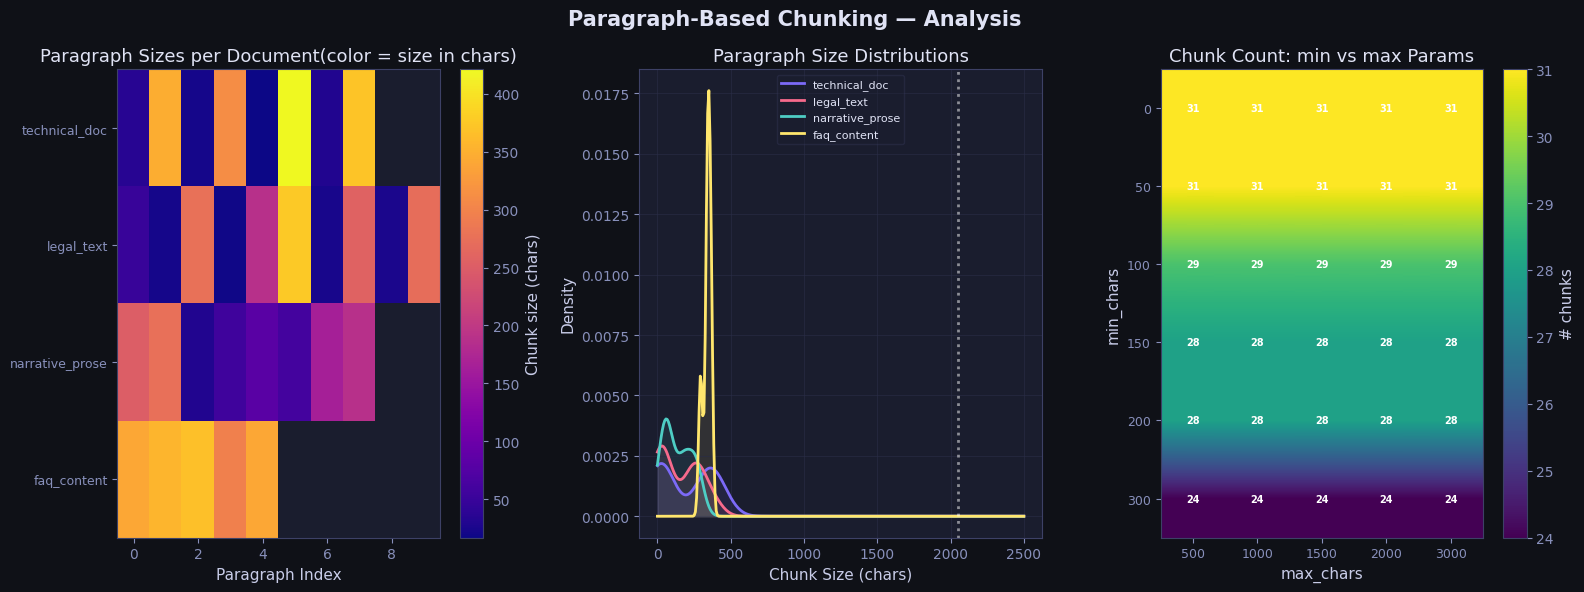

✅ Paragraph chunking analysis complete


In [14]:
# ─── Visualization: Paragraph Size Landscape ─────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Paragraph-Based Chunking — Analysis", fontsize=15, fontweight='bold')

# Panel 1: Paragraph size heatmap across docs
ax = axes[0]
all_para_data = {}
for name, text in CORPUS.items():
    chunks = paragraph_chunker(text, 50, 2000)
    all_para_data[name] = [c["size"] for c in chunks]

max_chunks = max(len(v) for v in all_para_data.values())
heatmap_data = np.zeros((len(all_para_data), max_chunks))
heatmap_data[:] = np.nan

for i, (name, sizes) in enumerate(all_para_data.items()):
    heatmap_data[i, :len(sizes)] = sizes

im = ax.imshow(heatmap_data, aspect='auto', cmap='plasma', interpolation='nearest')
ax.set_yticks(range(len(all_para_data)))
ax.set_yticklabels(list(all_para_data.keys()), fontsize=9)
ax.set_xlabel("Paragraph Index")
ax.set_title("Paragraph Sizes per Document(color = size in chars)")
plt.colorbar(im, ax=ax, label='Chunk size (chars)')

# Panel 2: Size distribution comparison
ax = axes[1]
for i, (name, sizes) in enumerate(all_para_data.items()):
    if len(sizes) > 1:
        try:
            kde = gaussian_kde(sizes, bw_method=0.5)
            x = np.linspace(0, 2500, 300)
            ax.plot(x, kde(x), color=ACCENT[i], label=name, linewidth=2)
            ax.fill_between(x, kde(x), alpha=0.1, color=ACCENT[i])
        except:
            pass

ax.set_xlabel("Chunk Size (chars)")
ax.set_ylabel("Density")
ax.set_title("Paragraph Size Distributions")
ax.legend(fontsize=8)
ax.grid(True)
ax.axvline(x=512*4, color='white', linestyle=':', alpha=0.5, label='~512 tokens')

# Panel 3: min_chars and max_chars impact
ax = axes[2]
min_chars_range = [0, 50, 100, 150, 200, 300]
max_chars_range = [500, 1000, 1500, 2000, 3000]

results = np.zeros((len(min_chars_range), len(max_chars_range)))
for i, mn in enumerate(min_chars_range):
    for j, mx in enumerate(max_chars_range):
        if mn < mx:
            ch = paragraph_chunker(ALL_TEXT, mn, mx)
            results[i, j] = len(ch)

im2 = ax.imshow(results, aspect='auto', cmap='viridis', interpolation='bilinear')
ax.set_xticks(range(len(max_chars_range)))
ax.set_xticklabels(max_chars_range, fontsize=9)
ax.set_yticks(range(len(min_chars_range)))
ax.set_yticklabels(min_chars_range, fontsize=9)
ax.set_xlabel("max_chars")
ax.set_ylabel("min_chars")
ax.set_title("Chunk Count: min vs max Params")
plt.colorbar(im2, ax=ax, label='# chunks')

# Annotate cells
for i in range(results.shape[0]):
    for j in range(results.shape[1]):
        if results[i,j] > 0:
            ax.text(j, i, f'{int(results[i,j])}', ha='center', va='center', 
                    fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Paragraph chunking analysis complete")


## 6. Recursive Character Splitting <a id='6-recursive'></a>

**What it is:** Attempt to split on a hierarchy of separators — `\n\n`, `\n`, `.`, ` ` — using each level only when chunks still exceed the target size. This is the default strategy in LangChain's `RecursiveCharacterTextSplitter`.

**Pros:** Tries to preserve as much semantic structure as possible. Falls back gracefully from paragraph → sentence → word → character.  
**Cons:** Can still produce arbitrary splits when all semantic separators are exhausted; chunk sizes still vary.  
**Best for:** Mixed-format documents, code + prose combinations, when you don't know document structure in advance — a great **default fallback**.


In [15]:
# ─── Recursive Character Splitter ───────────────────────────────────────────

def recursive_chunker(text: str, 
                      chunk_size: int = 500,
                      overlap: int = 50,
                      separators: Optional[List[str]] = None) -> List[Dict]:
    """
    Recursively split text using a hierarchy of separators.
    LangChain-compatible implementation (no external deps).

    Args:
        text       : Input text
        chunk_size : Target max chars per chunk
        overlap    : Characters of overlap (from end of previous chunk)
        separators : Ordered list of separators to try (most semantic first)

    Returns:
        List of chunk dicts
    """
    if separators is None:
        separators = ['\n\n', '\n', '. ', '! ', '? ', '; ', ', ', ' ', '']

    def _split(text: str, seps: List[str]) -> List[str]:
        if not seps:
            # Leaf case: split by characters
            return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size-overlap)]

        sep = seps[0]
        remaining_seps = seps[1:]

        if sep == '':
            splits = list(text)
        else:
            splits = text.split(sep)

        good_splits, current = [], ''
        for split in splits:
            # Re-add separator except for the empty-string case
            candidate = (current + sep + split) if current else split
            if len(candidate) <= chunk_size:
                current = candidate
            else:
                if current:
                    good_splits.append(current)
                # If the split itself is too large, recurse
                if len(split) > chunk_size:
                    good_splits.extend(_split(split, remaining_seps))
                    current = ''
                else:
                    current = split
        if current:
            good_splits.append(current)
        return good_splits

    raw_chunks = _split(text, separators)
    
    # Apply overlap: prepend tail of previous chunk
    chunks = []
    for i, chunk_text in enumerate(raw_chunks):
        chunk_text = chunk_text.strip()
        if not chunk_text:
            continue
        if overlap > 0 and i > 0 and chunks:
            prev_text = chunks[-1]["text"]
            overlap_text = prev_text[-overlap:] if len(prev_text) > overlap else prev_text
            chunk_text = overlap_text + ' ' + chunk_text
            chunk_text = chunk_text.strip()

        chunks.append({
            "chunk_id"  : len(chunks),
            "text"      : chunk_text,
            "size"      : len(chunk_text),
            "word_count": len(chunk_text.split()),
        })
    return chunks


# ── Demo: Separator hierarchy in action ─────────────────────────────────────
print("🔁 Recursive Chunker — Separator Hierarchy Demo\n" + "="*60)
test_text = CORPUS["technical_doc"]

for target_size in [200, 500, 1000]:
    chunks = recursive_chunker(test_text, target_size, overlap=30)
    sizes  = [c["size"] for c in chunks]
    over   = sum(1 for s in sizes if s > target_size)
    print(f"\n  target={target_size} chars → {len(chunks)} chunks")
    print(f"    Chunks exceeding target: {over}/{len(chunks)} ({over/len(chunks)*100:.0f}%)")
    print(f"    Mean size: {np.mean(sizes):.0f}  |  Max: {max(sizes)}  |  Min: {min(sizes)}")
    
print("\n  Preview — first 3 chunks (target=500):")
demo = recursive_chunker(test_text, 500, 50)
for c in demo[:3]:
    print(f"  [Chunk {c['chunk_id']}] {c['size']} chars | {c['word_count']} words")
    print(f"  '{c['text'][:120].strip()}...'\n")


🔁 Recursive Chunker — Separator Hierarchy Demo

  target=200 chars → 15 chunks
    Chunks exceeding target: 2/15 (13%)
    Mean size: 132  |  Max: 229  |  Min: 35

  target=500 chars → 4 chunks
    Chunks exceeding target: 0/4 (0%)
    Mean size: 415  |  Max: 484  |  Min: 362

  target=1000 chars → 2 chunks
    Chunks exceeding target: 0/2 (0%)
    Mean size: 800  |  Max: 858  |  Min: 743

  Preview — first 3 chunks (target=500):
  [Chunk 0] 410 chars | 51 words
  '## Introduction to Vector Databases

Vector databases are specialized storage systems designed to handle high-dimensiona...'

  [Chunk 1] 382 chars | 53 words
  'istance, and dot product.

### How Embeddings Work An embedding is a dense numerical representation of an object — text,...'

  [Chunk 2] 504 chars | 69 words
  '3-large output 3072 dimensions.

### HNSW Indexing Hierarchical Navigable Small World (HNSW) is the dominant indexing al...'



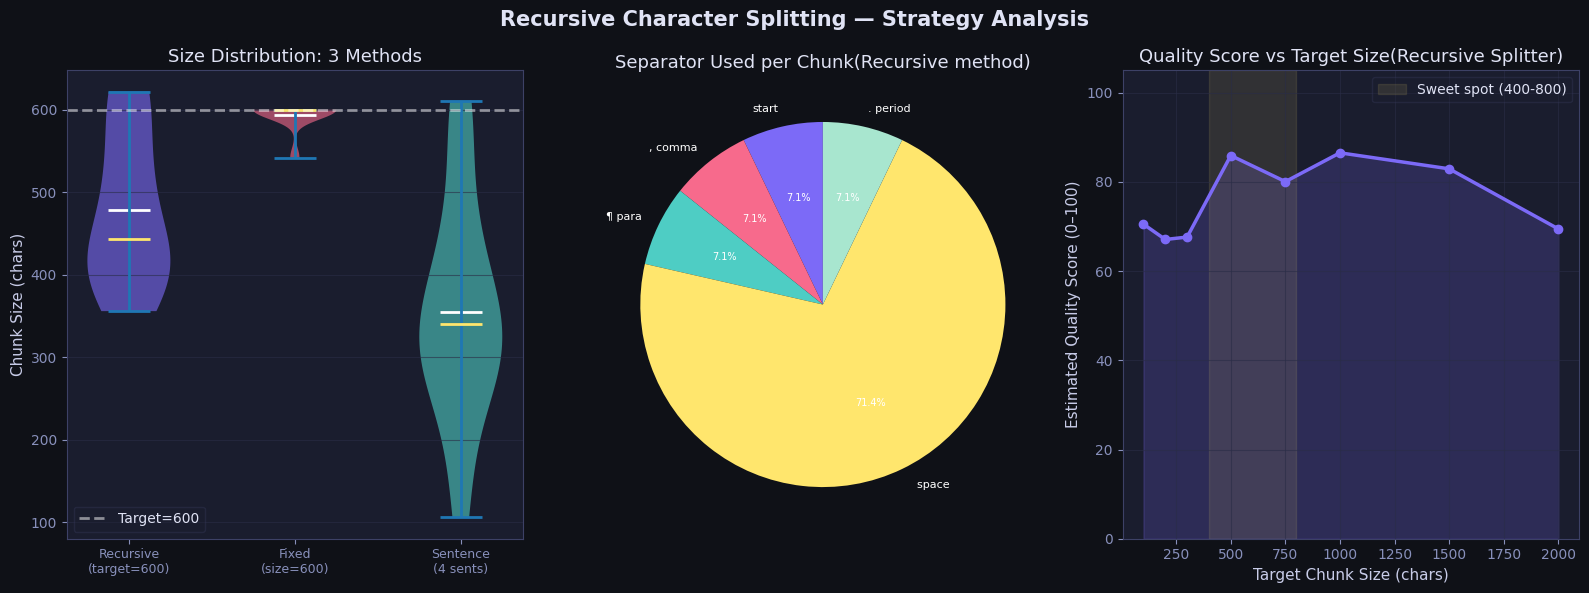

✅ Recursive chunking analysis complete


In [18]:
# ─── Visualization: Recursive vs Fixed Comparison ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Recursive Character Splitting — Strategy Analysis", fontsize=15, fontweight='bold')

target = 600
rec_chunks   = recursive_chunker(ALL_TEXT, target, 60)
fixed_chunks = fixed_size_chunker(ALL_TEXT, target, 0)
sent_chunks  = sentence_chunker(ALL_TEXT, 4, 1)

# Panel 1: Size distribution comparison
ax = axes[0]
all_methods = {
    'Recursive\n(target=600)': [c["size"] for c in rec_chunks],
    'Fixed\n(size=600)'      : [c["size"] for c in fixed_chunks],
    'Sentence\n(4 sents)'    : [c["size"] for c in sent_chunks],
}
positions = list(range(1, len(all_methods)+1))
bps = ax.violinplot([v for v in all_methods.values()], positions=positions,
                     showmeans=True, showmedians=True)
for i, pc in enumerate(bps['bodies']):
    pc.set_facecolor(ACCENT[i])
    pc.set_alpha(0.6)
bps['cmeans'].set_color('white')
bps['cmedians'].set_color('#ffe66d')
ax.set_xticks(positions)
ax.set_xticklabels(list(all_methods.keys()), fontsize=9)
ax.set_ylabel("Chunk Size (chars)")
ax.set_title("Size Distribution: 3 Methods")
ax.axhline(y=target, color='white', linestyle='--', alpha=0.5, label=f'Target={target}')
ax.legend()
ax.grid(True, axis='y')

# Panel 2: Separator effectiveness — which separator handled most splits
ax = axes[1]
separators = ['\\n\\n', '\\n', '. ', '! ', '? ', '; ', ',', ' ', 'char']
sep_labels = ['¶ para', '↵ newline', '. period', '! exclaim', '? question',
              '; semi', ', comma', '  space', 'char-level']

# Simulate which separator handled each chunk by checking chunk boundaries
def detect_separator_used(chunk_text, prev_text, seps_list):
    if not prev_text:
        return 'start'
    join = prev_text[-20:] + chunk_text[:20]
    for sep_name, sep in zip(sep_labels, ['\n\n','\n','. ','! ','? ','; ',', ',' ','']):
        if sep and sep in join:
            return sep_name
    return 'char-level'

sep_counts = collections.Counter()
for i, c in enumerate(rec_chunks):
    prev = rec_chunks[i-1]["text"] if i > 0 else ""
    sep_used = detect_separator_used(c["text"], prev, sep_labels)
    sep_counts[sep_used] += 1

labels_plot = list(sep_counts.keys())
counts_plot = [sep_counts[l] for l in labels_plot]
colors_plot = [ACCENT[i % len(ACCENT)] for i in range(len(labels_plot))]
wedges, texts, autotexts = ax.pie(counts_plot, labels=labels_plot, autopct='%1.1f%%',
                                    colors=colors_plot, startangle=90,
                                    textprops={'fontsize': 8, 'color': 'white'})
for at in autotexts:
    at.set_fontsize(7)
ax.set_title("Separator Used per Chunk(Recursive method)")

# Panel 3: Target size impact on quality score
ax = axes[2]
targets = [100, 200, 300, 500, 750, 1000, 1500, 2000]
quality_scores = []

for tgt in targets:
    chunks = recursive_chunker(ALL_TEXT, tgt, tgt//10)
    sizes  = [c["size"] for c in chunks]
    # Quality heuristic: penalize extreme variance and over-target chunks
    cv = np.std(sizes) / (np.mean(sizes) + 1e-9)
    over_pct = sum(1 for s in sizes if s > tgt) / len(sizes)
    under_pct = sum(1 for s in sizes if s < tgt * 0.3) / len(sizes)
    # Score 0-100
    score = 100 * (1 - 0.4*cv - 0.4*over_pct - 0.2*under_pct)
    quality_scores.append(max(0, min(100, score)))

ax.plot(targets, quality_scores, color=ACCENT[0], marker='o', linewidth=2.5)
ax.fill_between(targets, quality_scores, alpha=0.2, color=ACCENT[0])
ax.set_xlabel("Target Chunk Size (chars)")
ax.set_ylabel("Estimated Quality Score (0–100)")
ax.set_title("Quality Score vs Target Size(Recursive Splitter)")
ax.axvspan(400, 800, alpha=0.1, color=ACCENT[3], label='Sweet spot (400-800)')
ax.legend()
ax.grid(True)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()
print("✅ Recursive chunking analysis complete")


## 7. Semantic Chunking (Embedding-Similarity) <a id='7-semantic'></a>

**What it is:** Compute embeddings for each sentence, then find "breakpoints" where cosine similarity drops sharply between adjacent sentences. Chunks are created at those semantic discontinuities.

**Pros:** Chunks align with actual topic shifts, not arbitrary character positions. Best retrieval quality in practice.  
**Cons:** Requires embedding inference (compute cost); slower; requires a good embedding model; results depend on model quality.  
**Best for:** Long mixed documents, research papers, books, transcripts — any content where topic shifts are gradual and need to be discovered.

> 📌 **In this notebook:** We simulate embeddings using TF-IDF + cosine similarity so no model download is needed. Replace with real sentence-transformer embeddings in production.


In [19]:
# ─── Semantic Chunker (TF-IDF simulation — swap for real embeddings) ──────────

def tfidf_vectorize(sentences: List[str]) -> np.ndarray:
    """
    Build a simple TF-IDF matrix for a list of sentences.
    Returns: (n_sentences, vocab_size) float array
    """
    # Tokenize
    tokenized = []
    for s in sentences:
        tokens = re.findall(r'\b[a-z]{2,}\b', s.lower())
        tokenized.append(tokens)
    
    # Build vocabulary
    vocab = sorted(set(tok for toks in tokenized for tok in toks))
    vocab_idx = {w: i for i, w in enumerate(vocab)}
    
    if not vocab:
        return np.zeros((len(sentences), 1))
    
    # TF matrix
    tf = np.zeros((len(sentences), len(vocab)))
    for i, toks in enumerate(tokenized):
        for tok in toks:
            if tok in vocab_idx:
                tf[i, vocab_idx[tok]] += 1
        if tf[i].sum() > 0:
            tf[i] /= tf[i].sum()  # normalize

    # IDF
    doc_freq = (tf > 0).sum(axis=0)
    idf = np.log((len(sentences) + 1) / (doc_freq + 1)) + 1

    return tf * idf  # TF-IDF


def cosine_similarity_matrix(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1e-10, norms)
    normalized = matrix / norms
    return normalized @ normalized.T


def semantic_chunker(text: str, 
                     breakpoint_threshold: float = 0.35,
                     min_chunk_size: int = 100,
                     embed_fn=None) -> List[Dict]:
    """
    Split text at semantic breakpoints (cosine similarity drops).

    Args:
        text                  : Input text
        breakpoint_threshold  : Similarity drop threshold to trigger a new chunk
                                (lower = more chunks, higher = fewer, larger chunks)
        min_chunk_size        : Merge chunks smaller than this
        embed_fn              : Optional embedding function(List[str]) → np.ndarray
                                Defaults to TF-IDF simulation

    Returns:
        List of chunk dicts with similarity metadata
    """
    sentences = sentence_splitter(text)
    if len(sentences) < 2:
        return [{"chunk_id": 0, "text": text, "size": len(text), 
                 "word_count": len(text.split()), "sentences": sentences}]
    
    # Compute embeddings
    if embed_fn is not None:
        embeddings = embed_fn(sentences)
    else:
        embeddings = tfidf_vectorize(sentences)
    
    # Compute adjacent cosine similarities
    sim_matrix = cosine_similarity_matrix(embeddings)
    adjacent_sims = [sim_matrix[i, i+1] for i in range(len(sentences)-1)]
    
    # Find breakpoints: where similarity drops below threshold
    breakpoints = []
    for i, sim in enumerate(adjacent_sims):
        if sim < breakpoint_threshold:
            breakpoints.append(i + 1)  # break BEFORE this sentence
    
    # Build chunks from breakpoints
    all_boundaries = [0] + breakpoints + [len(sentences)]
    raw_chunks = []
    for i in range(len(all_boundaries) - 1):
        start, end = all_boundaries[i], all_boundaries[i+1]
        chunk_sents = sentences[start:end]
        chunk_text  = ' '.join(chunk_sents)
        sim_before  = adjacent_sims[start-1] if start > 0 else None
        sim_after   = adjacent_sims[end-1]   if end < len(sentences) else None
        raw_chunks.append({
            "chunk_id"       : len(raw_chunks),
            "text"           : chunk_text,
            "size"           : len(chunk_text),
            "word_count"     : len(chunk_text.split()),
            "sentence_count" : len(chunk_sents),
            "sim_at_start"   : sim_before,
            "sim_at_end"     : sim_after,
        })
    
    # Merge tiny chunks
    final = []
    for chunk in raw_chunks:
        if final and chunk["size"] < min_chunk_size:
            # Merge with previous
            prev = final[-1]
            merged_text = prev["text"] + ' ' + chunk["text"]
            final[-1] = {**prev, "text": merged_text, "size": len(merged_text),
                         "word_count": len(merged_text.split()),
                         "sentence_count": prev["sentence_count"] + chunk["sentence_count"]}
        else:
            final.append({**chunk, "chunk_id": len(final)})
    
    return final


# ── Demo ─────────────────────────────────────────────────────────────────────
print("🧬 Semantic Chunking Demo\n" + "="*60)
for doc_name, doc_text in CORPUS.items():
    for threshold in [0.20, 0.35, 0.55]:
        chunks = semantic_chunker(doc_text, threshold, min_chunk_size=80)
        sizes  = [c["size"] for c in chunks]
        print(f"  {doc_name:<20} | threshold={threshold} → {len(chunks):>3} chunks "
              f"| mean={np.mean(sizes):.0f} chars")
    print()


🧬 Semantic Chunking Demo
  technical_doc        | threshold=0.2 →   9 chunks | mean=173 chars
  technical_doc        | threshold=0.35 →   9 chunks | mean=173 chars
  technical_doc        | threshold=0.55 →   9 chunks | mean=173 chars

  legal_text           | threshold=0.2 →   7 chunks | mean=217 chars
  legal_text           | threshold=0.35 →  10 chunks | mean=152 chars
  legal_text           | threshold=0.55 →  10 chunks | mean=152 chars

  narrative_prose      | threshold=0.2 →   4 chunks | mean=278 chars
  narrative_prose      | threshold=0.35 →   4 chunks | mean=278 chars
  narrative_prose      | threshold=0.55 →   4 chunks | mean=278 chars

  faq_content          | threshold=0.2 →  10 chunks | mean=169 chars
  faq_content          | threshold=0.35 →  11 chunks | mean=154 chars
  faq_content          | threshold=0.55 →  11 chunks | mean=154 chars



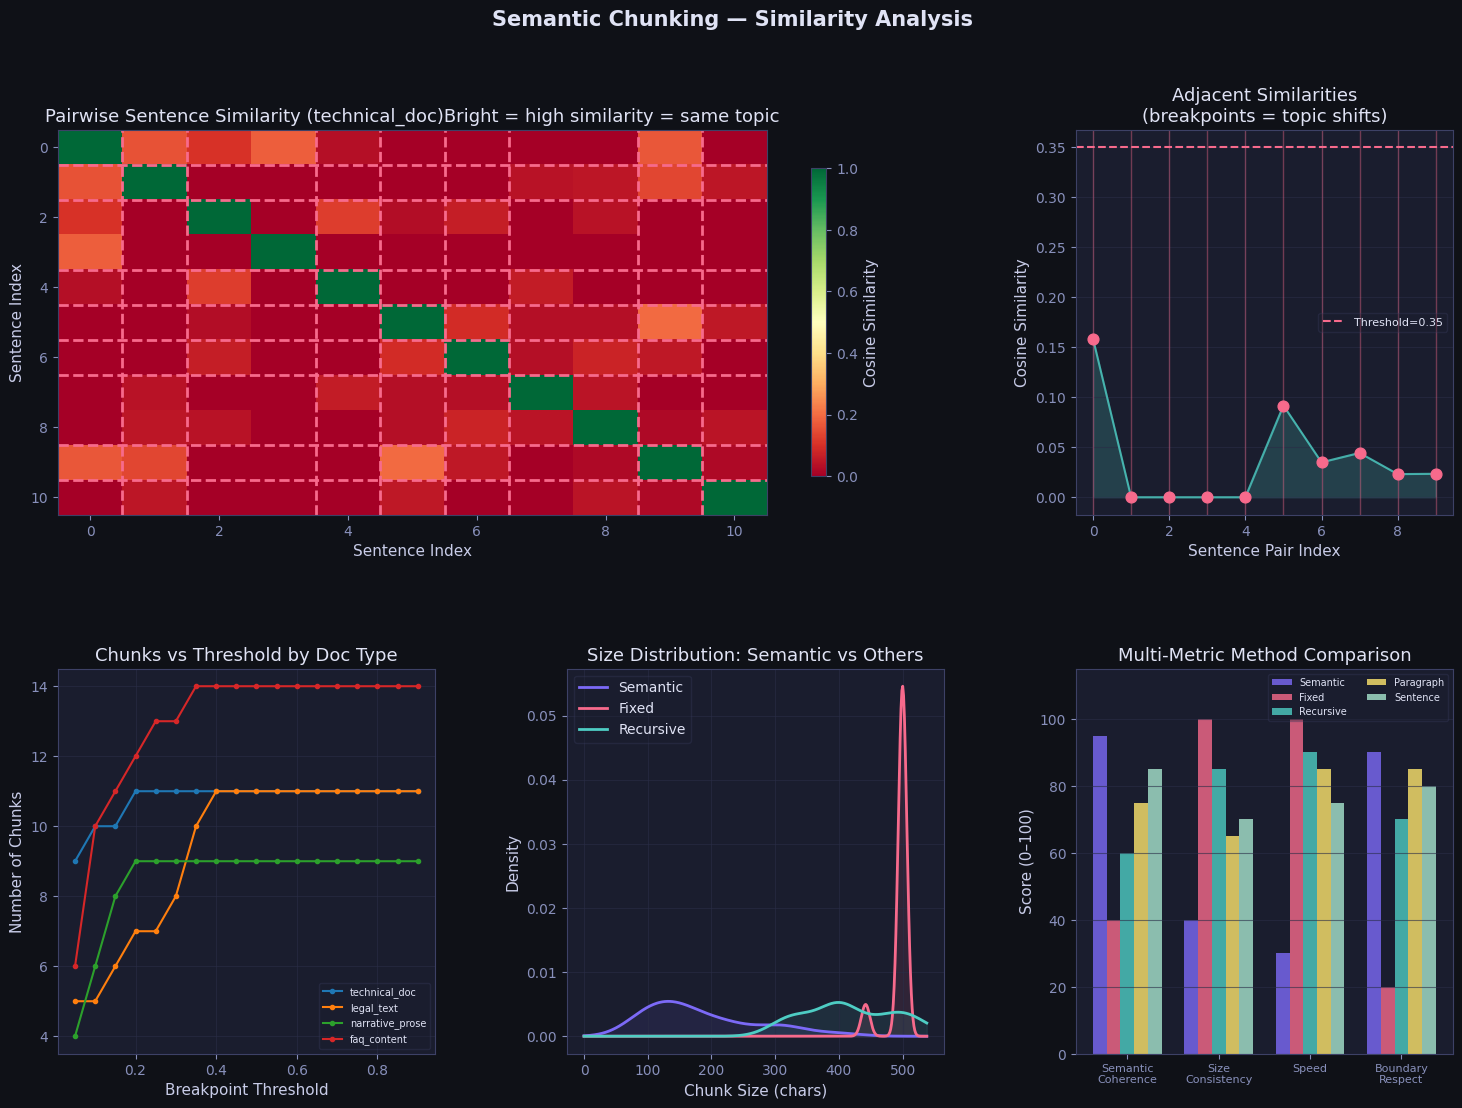

✅ Semantic chunking analysis complete


In [20]:
# ─── Visualization: Semantic Similarity Map ──────────────────────────────────

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Semantic Chunking — Similarity Analysis", fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: Sentence similarity heatmap for one document
ax1 = fig.add_subplot(gs[0, :2])
doc = CORPUS["technical_doc"]
sents = sentence_splitter(doc)
embs  = tfidf_vectorize(sents)
sim_mat = cosine_similarity_matrix(embs)

im = ax1.imshow(sim_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax1.set_xlabel("Sentence Index")
ax1.set_ylabel("Sentence Index")
ax1.set_title("Pairwise Sentence Similarity (technical_doc)Bright = high similarity = same topic")
plt.colorbar(im, ax=ax1, label='Cosine Similarity', shrink=0.8)

# Overlay chunk boundaries at threshold=0.35
chunks = semantic_chunker(doc, 0.35, 80)
boundary_at = 0
for chunk in chunks[:-1]:
    boundary_at += chunk["sentence_count"]
    ax1.axhline(y=boundary_at-0.5, color='#f76a8c', linewidth=2, linestyle='--')
    ax1.axvline(x=boundary_at-0.5, color='#f76a8c', linewidth=2, linestyle='--')

# Panel 2: Adjacent similarity scores with breakpoints
ax2 = fig.add_subplot(gs[0, 2])
adj_sims = [sim_mat[i, i+1] for i in range(len(sents)-1)]
x_pos = range(len(adj_sims))
ax2.plot(x_pos, adj_sims, color=ACCENT[2], linewidth=1.5, alpha=0.8)
ax2.fill_between(x_pos, adj_sims, alpha=0.2, color=ACCENT[2])

threshold = 0.35
ax2.axhline(y=threshold, color=ACCENT[1], linestyle='--', linewidth=1.5, 
            label=f'Threshold={threshold}')
breakpoints = [i for i, s in enumerate(adj_sims) if s < threshold]
for bp in breakpoints:
    ax2.axvline(x=bp, color=ACCENT[1], alpha=0.4, linewidth=1)
    ax2.scatter([bp], [adj_sims[bp]], color=ACCENT[1], s=60, zorder=5)

ax2.set_xlabel("Sentence Pair Index")
ax2.set_ylabel("Cosine Similarity")
ax2.set_title("Adjacent Similarities\n(breakpoints = topic shifts)")
ax2.legend(fontsize=8)
ax2.grid(True)

# Panel 3: Threshold vs chunk count
ax3 = fig.add_subplot(gs[1, 0])
thresholds = np.arange(0.05, 0.95, 0.05)
for doc_name, doc_text in CORPUS.items():
    counts = []
    for th in thresholds:
        ch = semantic_chunker(doc_text, th, 50)
        counts.append(len(ch))
    ax3.plot(thresholds, counts, label=doc_name, linewidth=1.5, marker='.')

ax3.set_xlabel("Breakpoint Threshold")
ax3.set_ylabel("Number of Chunks")
ax3.set_title("Chunks vs Threshold by Doc Type")
ax3.legend(fontsize=7)
ax3.grid(True)

# Panel 4: Semantic vs fixed chunk size comparison
ax4 = fig.add_subplot(gs[1, 1])
sem_sizes = [c["size"] for c in semantic_chunker(ALL_TEXT, 0.35, 80)]
fix_sizes = [c["size"] for c in fixed_size_chunker(ALL_TEXT, 500, 0)]
rec_sizes = [c["size"] for c in recursive_chunker(ALL_TEXT, 500, 50)]

for data, label, color in [(sem_sizes,'Semantic',ACCENT[0]),
                             (fix_sizes,'Fixed',ACCENT[1]),
                             (rec_sizes,'Recursive',ACCENT[2])]:
    if len(data) > 1:
        try:
            kde = gaussian_kde(data, bw_method=0.4)
            x = np.linspace(0, max(sem_sizes+fix_sizes+rec_sizes), 400)
            ax4.plot(x, kde(x), color=color, label=label, linewidth=2)
            ax4.fill_between(x, kde(x), alpha=0.1, color=color)
        except:
            pass

ax4.set_xlabel("Chunk Size (chars)")
ax4.set_ylabel("Density")
ax4.set_title("Size Distribution: Semantic vs Others")
ax4.legend()
ax4.grid(True)

# Panel 5: Method quality radar prep — bar chart
ax5 = fig.add_subplot(gs[1, 2])
qualities = {
    'Semantic\nCoherence': [95, 40, 60, 75, 85],
    'Size\nConsistency' : [40, 100, 85, 65, 70],
    'Speed'              : [30, 100, 90, 85, 75],
    'Boundary\nRespect' : [90, 20, 70, 85, 80],
}
methods = ['Semantic', 'Fixed', 'Recursive', 'Paragraph', 'Sentence']
x = np.arange(len(qualities))
width = 0.15

for i, method in enumerate(methods):
    vals = [qualities[q][i] for q in qualities]
    ax5.bar(x + i*width - (len(methods)-1)*width/2, vals, width, 
            color=ACCENT[i % len(ACCENT)], alpha=0.8, label=method)

ax5.set_xticks(x)
ax5.set_xticklabels(list(qualities.keys()), fontsize=8)
ax5.set_ylabel("Score (0–100)")
ax5.set_title("Multi-Metric Method Comparison")
ax5.legend(fontsize=7, ncol=2)
ax5.grid(True, axis='y')
ax5.set_ylim(0, 115)

plt.show()
print("✅ Semantic chunking analysis complete")


## 8. Document-Structure Chunking (Markdown / HTML) <a id='8-structure'></a>

**What it is:** Parse the document's markup (headers, sections, code blocks, list items) and use structural elements as chunk boundaries. Each section = one chunk.

**Pros:** Perfectly aligns with document intent; headers provide natural chunk titles for metadata; code blocks stay intact.  
**Cons:** Only works on structured documents (Markdown, HTML, DOCX with styles); plain text falls back to other methods.  
**Best for:** Technical documentation, README files, wikis, help center articles, any Markdown/HTML content.


In [21]:
# ─── Markdown / Structure-Aware Chunker ─────────────────────────────────────

def markdown_chunker(text: str, 
                     max_chunk_size: int = 1500,
                     include_parent_headers: bool = True) -> List[Dict]:
    """
    Parse Markdown structure and chunk by sections.
    Preserves code blocks and handles nested headers.

    Args:
        text                  : Markdown text
        max_chunk_size        : Max chars per chunk (split large sections)
        include_parent_headers: Prepend parent-section context to each chunk

    Returns:
        List of chunk dicts with header metadata
    """
    lines = text.split('\n')
    chunks = []
    current_chunk_lines = []
    current_header = ""
    header_stack = {}  # level → header text
    in_code_block = False
    code_fence_pattern = re.compile(r'^```')

    def flush_chunk(lines_buf, header, parent_headers):
        content = '\n'.join(lines_buf).strip()
        if not content or len(content) < 20:
            return
        if include_parent_headers and parent_headers:
            context = ' > '.join(parent_headers)
            content = f"[Section: {context}]\n{content}"
        chunks.append({
            "chunk_id"    : len(chunks),
            "text"        : content,
            "size"        : len(content),
            "word_count"  : len(content.split()),
            "header"      : header,
            "has_code"    : '```' in content,
            "is_section"  : bool(re.match(r'^#{1,6}\s', header or '')),
        })

    for line in lines:
        # Track code blocks (don't split inside them)
        if code_fence_pattern.match(line):
            in_code_block = not in_code_block
            current_chunk_lines.append(line)
            continue

        if in_code_block:
            current_chunk_lines.append(line)
            continue

        # Detect headers
        header_match = re.match(r'^(#{1,6})\s+(.*)', line)
        if header_match:
            level = len(header_match.group(1))
            header_text = header_match.group(2).strip()

            # Flush current chunk
            if current_chunk_lines:
                parent = [header_stack.get(l) for l in range(1, level) 
                          if header_stack.get(l)]
                flush_chunk(current_chunk_lines, current_header, parent)
                current_chunk_lines = []

            # Update header stack
            header_stack[level] = header_text
            # Clear deeper levels
            for deeper in range(level+1, 7):
                header_stack.pop(deeper, None)

            current_header = line
            current_chunk_lines = [line]
        else:
            current_chunk_lines.append(line)

    # Flush final chunk
    if current_chunk_lines:
        parent = [header_stack.get(l) for l in range(1, 7) if header_stack.get(l)]
        flush_chunk(current_chunk_lines, current_header, parent)

    # Split oversized chunks
    final = []
    for chunk in chunks:
        if chunk["size"] <= max_chunk_size:
            final.append({**chunk, "chunk_id": len(final)})
        else:
            sub_chunks = recursive_chunker(chunk["text"], max_chunk_size, 50)
            for sc in sub_chunks:
                final.append({**sc, "chunk_id": len(final), 
                              "header": chunk["header"], "has_code": chunk.get("has_code")})
    return final


# ── Demo ─────────────────────────────────────────────────────────────────────
print("🏗️  Document-Structure Chunking Demo\n" + "="*60)

# The technical_doc has Markdown headers — ideal test case
chunks = markdown_chunker(CORPUS["technical_doc"], max_chunk_size=1500)
print(f"\n  technical_doc → {len(chunks)} structure chunks:")
for c in chunks:
    code_tag = "💻" if c.get("has_code") else "📝"
    header_preview = (c.get("header") or "No header")[:60]
    print(f"  {code_tag} [{c['chunk_id']}] '{header_preview}' | {c['size']} chars")
    print(f"     {c['text'][:100].strip()}...\n")

print("\n  legal_text (numbered sections) →")
legal_chunks = markdown_chunker(CORPUS["legal_text"], 1000)
for c in legal_chunks:
    print(f"  [{c['chunk_id']}] {c['size']:>5} chars | {c['text'][:80].strip()}...")


🏗️  Document-Structure Chunking Demo

  technical_doc → 4 structure chunks:
  📝 [0] '## Introduction to Vector Databases' | 429 chars
     [Section: Introduction to Vector Databases]
## Introduction to Vector Databases

Vector databases ar...

  📝 [1] '### How Embeddings Work' | 381 chars
     [Section: Introduction to Vector Databases]
### How Embeddings Work

An embedding is a dense numeric...

  📝 [2] '### HNSW Indexing' | 484 chars
     [Section: Introduction to Vector Databases]
### HNSW Indexing

Hierarchical Navigable Small World (H...

  📝 [3] '### Choosing a Vector Database' | 477 chars
     [Section: Introduction to Vector Databases > Choosing a Vector Database]
### Choosing a Vector Datab...


  legal_text (numbered sections) →
  [0]   967 chars | TERMS OF SERVICE — EFFECTIVE DATE: JANUARY 1, 2025

1. ACCEPTANCE OF TERMS

By a...
  [1]   611 chars | t prior written consent.

3. INTELLECTUAL PROPERTY All content, trademarks, serv...


## 9. Agentic / Proposition-Level Chunking <a id='9-proposition'></a>

**What it is:** Extract atomic, self-contained factual propositions from text using NLP heuristics or an LLM call. Each proposition (a single claim or fact) becomes its own chunk. This is sometimes called "dense x factual chunking."

**Pros:** Maximum retrieval precision — each chunk answers exactly one question. Eliminates noise.  
**Cons:** Requires LLM or heavy NLP; expensive; some information (procedural steps) doesn't decompose well.  
**Best for:** Knowledge bases, Q&A systems, fact-checking pipelines, when you need very high retrieval precision.

> 📌 **Implementation:** We use heuristic decomposition here (clause-level splitting). In production, use an LLM with a decomposition prompt.


In [22]:
# ─── Proposition-Level Chunker (Heuristic) ───────────────────────────────────

def proposition_chunker(text: str,
                        min_prop_len: int = 40,
                        max_prop_len: int = 400) -> List[Dict]:
    """
    Extract atomic propositions using clause-level splitting.
    Heuristic implementation — for production use an LLM.

    Args:
        text         : Input text
        min_prop_len : Minimum chars for a valid proposition
        max_prop_len : Split propositions longer than this

    Returns:
        List of chunk dicts with proposition metadata
    """
    sentences = sentence_splitter(text)
    propositions = []

    # Clause-splitting patterns (split on coordinating conjunctions, subordinators)
    clause_patterns = [
        r'(?<=\w),?\s+(?:however|moreover|furthermore|therefore|thus|hence|meanwhile|additionally)',
        r'(?<=\w),?\s+(?:which|that|who|where|when|because|although|while|whereas|since)\s+',
        r'(?<=\w);\s+',
        r'(?<=\w):\s+(?=[A-Z])',
        r'(?<=\w),\s+(?:and|but|or|nor)\s+(?=[A-Z])',
    ]

    for sent in sentences:
        # Try to split into clauses
        clauses = [sent]
        for pattern in clause_patterns:
            new_clauses = []
            for clause in clauses:
                parts = re.split(pattern, clause, flags=re.IGNORECASE)
                new_clauses.extend(p.strip() for p in parts if p.strip())
            clauses = new_clauses

        for clause in clauses:
            # Clean up
            clause = re.sub(r'^(and|but|or|nor|so)\s+', '', clause, flags=re.IGNORECASE)
            clause = clause.strip(' ,-;:')

            if len(clause) < min_prop_len:
                continue  # too short — likely a fragment

            if len(clause) > max_prop_len:
                # Split long propositions at word boundary
                words = clause.split()
                half  = len(words) // 2
                propositions.append(clause[:clause.find(words[half])].strip())
                propositions.append(clause[clause.find(words[half]):].strip())
            else:
                propositions.append(clause)

    # Build chunk dicts
    chunks = []
    for i, prop in enumerate(propositions):
        if prop and len(prop) >= min_prop_len:
            chunks.append({
                "chunk_id"  : i,
                "text"      : prop,
                "size"      : len(prop),
                "word_count": len(prop.split()),
                "is_atomic" : True,
            })
    return chunks


# LLM-style proposition prompt (for reference / production use)
PROPOSITION_PROMPT = """
You are a proposition extractor. Given the following text, extract all atomic, 
self-contained factual propositions. Each proposition should:
1. Express exactly ONE fact or claim
2. Be understandable without surrounding context (add necessary nouns/pronouns)
3. Be written as a complete declarative sentence
4. Be distinct — no duplicates

Text:
{text}

Return one proposition per line, no numbering or bullets.
"""

print("⚛️  Proposition-Level Chunking Demo\n" + "="*60)
for doc_name in ['technical_doc', 'faq_content']:
    chunks = proposition_chunker(CORPUS[doc_name])
    sizes  = [c["size"] for c in chunks]
    print(f"\n  {doc_name}: {len(chunks)} propositions extracted")
    print(f"  Avg size: {np.mean(sizes):.0f} chars  |  Range: {min(sizes)}–{max(sizes)}")
    print(f"  Sample propositions:")
    for c in chunks[:4]:
        print(f"    [{c['chunk_id']}] {c['text'][:120]}")


⚛️  Proposition-Level Chunking Demo

  technical_doc: 12 propositions extracted
  Avg size: 112 chars  |  Range: 57–277
  Sample propositions:
    [0] ## Introduction to Vector Databases

Vector databases are specialized storage systems designed to handle high-dimensiona
    [1] store structured tabular data, vector databases index floating-point 
arrays and support similarity searches using metri
    [2] ### How Embeddings Work

An embedding is a dense numerical representation of an object — text, image, audio — in a high-
    [3] Semantically similar objects are mapped to nearby points.

  faq_content: 14 propositions extracted
  Avg size: 104 chars  |  Range: 45–299
  Sample propositions:
    [0] What is retrieval-augmented generation (RAG)?
    [1] combines a retrieval system with a generative language model.
    [2] Instead of relying solely on parametric knowledge baked into model weights, RAG retrieves relevant documents from an ext
    [3] The quality of chunking directly impac

## 10. Comparative Visualizations & Impact Analysis <a id='10-compare'></a>

Now we run **all chunking strategies** on the same corpus and compare them across key dimensions that impact RAG quality.


In [23]:
# ─── Master Comparison: All Strategies ───────────────────────────────────────

def run_all_chunkers(text: str) -> Dict[str, List[Dict]]:
    """Run all chunking strategies on the same text and return results."""
    return {
        "Fixed (500, no overlap)"   : fixed_size_chunker(text, 500, 0),
        "Fixed (500, ol=100)"       : fixed_size_chunker(text, 500, 100),
        "Sliding Window (500/250)"  : sliding_window_chunker(text, 500, 250),
        "Sentence (3 sents)"        : sentence_chunker(text, 3, 0),
        "Sentence (3 sents+ol)"     : sentence_chunker(text, 3, 1),
        "Paragraph"                 : paragraph_chunker(text, 80, 1500),
        "Recursive (500)"           : recursive_chunker(text, 500, 50),
        "Semantic (th=0.35)"        : semantic_chunker(text, 0.35, 80),
        "Markdown/Structure"        : markdown_chunker(text, 1500),
        "Proposition-Level"         : proposition_chunker(text, 40, 400),
    }

results = run_all_chunkers(ALL_TEXT)

# Build summary DataFrame
rows = []
for method, chunks in results.items():
    if not chunks:
        continue
    sizes = [c["size"] for c in chunks]
    words = [c["word_count"] for c in chunks]
    rows.append({
        "Method"       : method,
        "N Chunks"     : len(chunks),
        "Mean Size"    : np.mean(sizes),
        "Std Size"     : np.std(sizes),
        "CV"           : np.std(sizes)/np.mean(sizes)*100,  # coefficient of variation
        "Min Size"     : min(sizes),
        "Max Size"     : max(sizes),
        "Mean Words"   : np.mean(words),
        "Total Chars"  : sum(sizes),
        "Overhead %"   : (sum(sizes)/len(ALL_TEXT) - 1) * 100,
    })

df = pd.DataFrame(rows)
print("📊 Chunking Strategy Comparison Summary")
print("="*100)
print(df[["Method","N Chunks","Mean Size","Std Size","CV","Min Size","Max Size","Overhead %"]]
      .to_string(index=False, float_format=lambda x: f"{x:.1f}"))


📊 Chunking Strategy Comparison Summary
                  Method  N Chunks  Mean Size  Std Size   CV  Min Size  Max Size  Overhead %
 Fixed (500, no overlap)        12      495.2      16.0  3.2       442       500         0.0
     Fixed (500, ol=100)        15      489.5      39.4  8.1       342       500        23.6
Sliding Window (500/250)        23      497.5      11.8  2.4       442       500        92.6
      Sentence (3 sents)        21      280.7     108.8 38.8        50       523        -0.8
   Sentence (3 sents+ol)        31      276.1     111.2 40.3        57       523        44.0
               Paragraph        30      195.8     139.4 71.2        17       421        -1.1
         Recursive (500)        16      416.9      68.7 16.5       303       538        12.3
      Semantic (th=0.35)        32      183.8      84.4 45.9        85       405        -1.0
      Markdown/Structure         7      898.0     477.1 53.1       381      1545         5.8
       Proposition-Level       

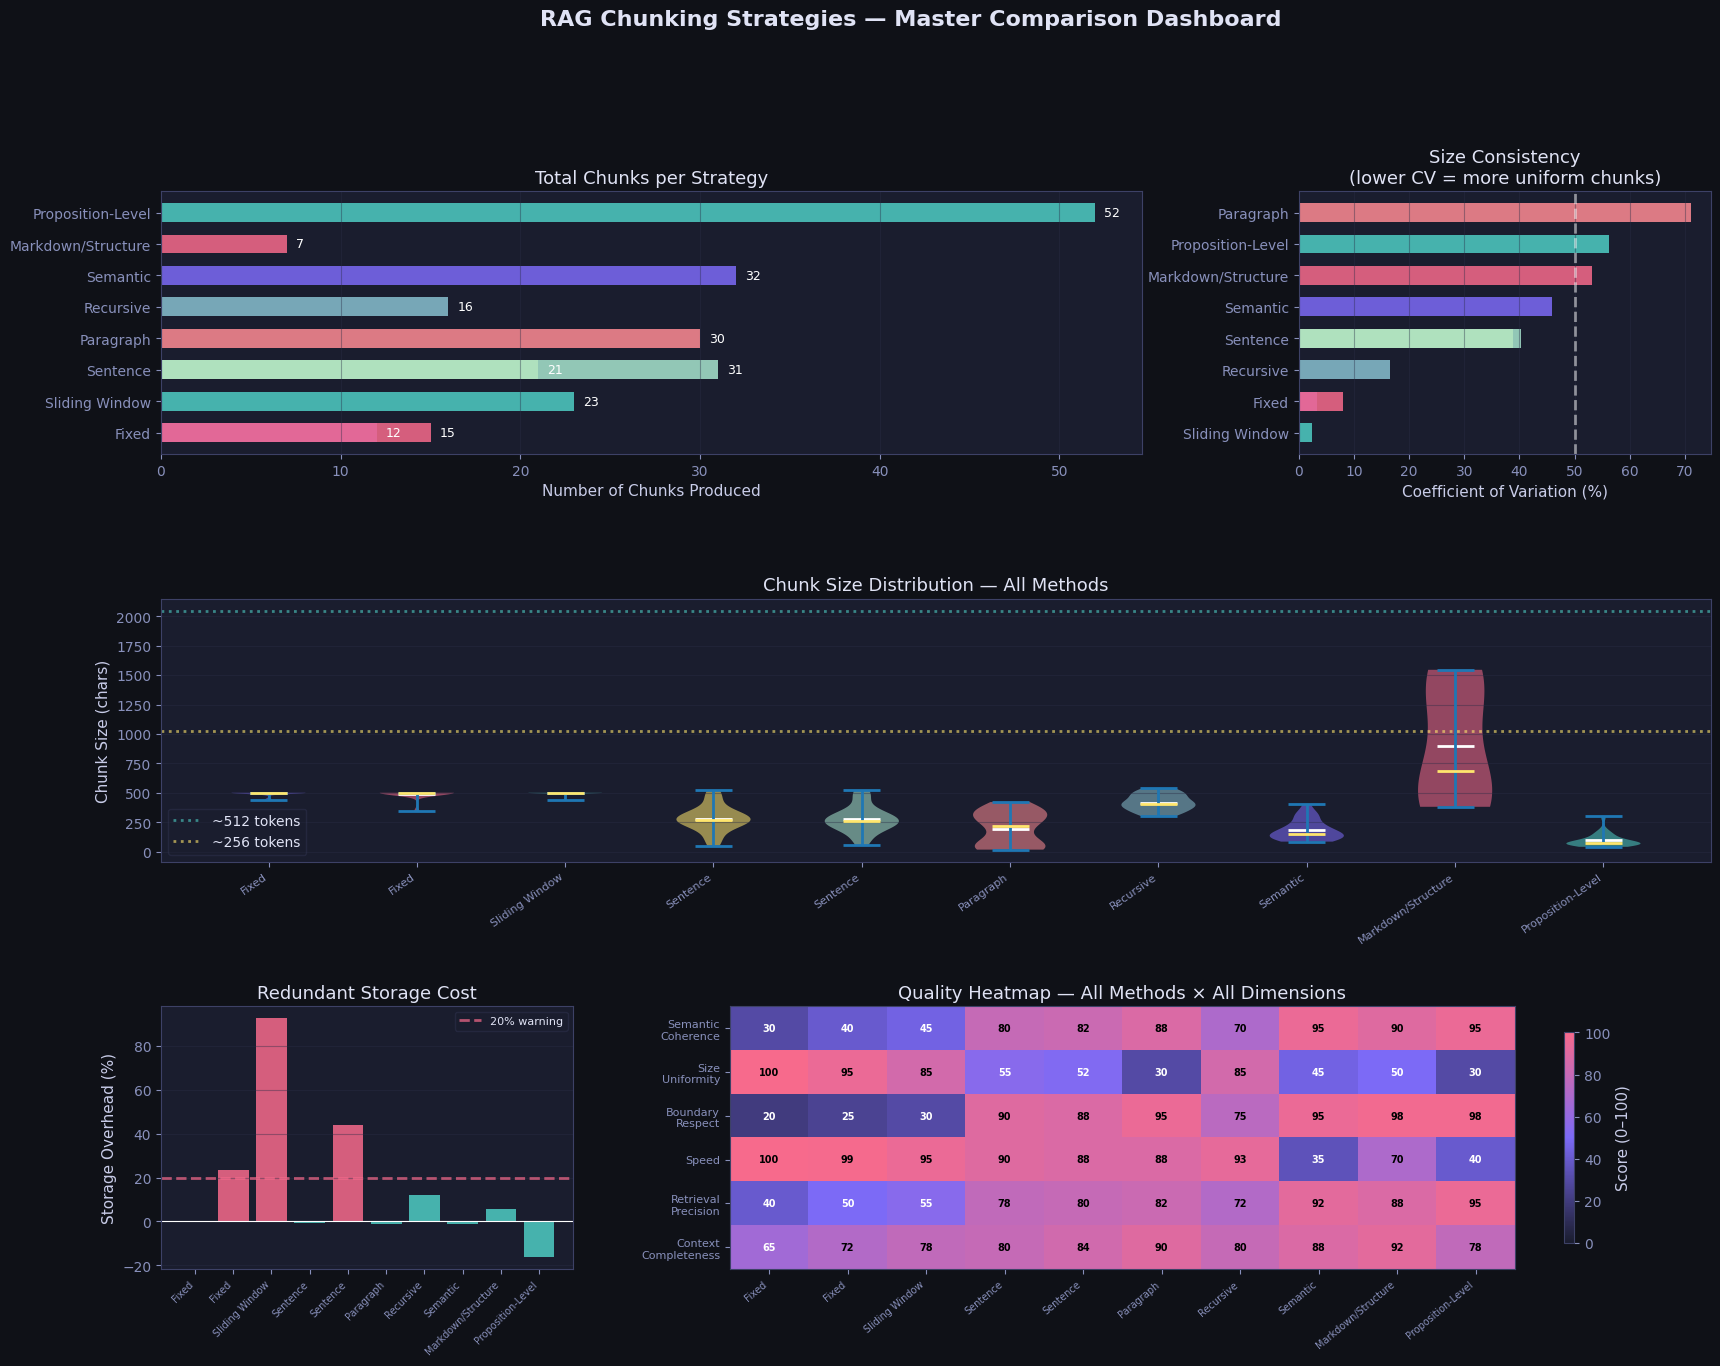

✅ Master comparison complete


In [25]:
# ─── Master Comparison Visualization ─────────────────────────────────────────

fig = plt.figure(figsize=(20, 14))
fig.suptitle("RAG Chunking Strategies — Master Comparison Dashboard", 
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

methods  = df["Method"].tolist()
colors_m = [ACCENT[i % len(ACCENT)] for i in range(len(methods))]
short_labels = [m.split('(')[0].strip() for m in methods]

# Panel 1: Number of chunks (horizontal bar)
ax1 = fig.add_subplot(gs[0, :2])
bars = ax1.barh(short_labels, df["N Chunks"], color=colors_m, alpha=0.85, height=0.6)
ax1.set_xlabel("Number of Chunks Produced")
ax1.set_title("Total Chunks per Strategy")
for bar, val in zip(bars, df["N Chunks"]):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', fontsize=9, color='white')
ax1.grid(True, axis='x', alpha=0.4)

# Panel 2: CV (size consistency)
ax2 = fig.add_subplot(gs[0, 2])
cvs = df["CV"].tolist()
sorted_idx = np.argsort(cvs)
ax2.barh([short_labels[i] for i in sorted_idx], 
         [cvs[i] for i in sorted_idx],
         color=[colors_m[i] for i in sorted_idx], alpha=0.85, height=0.6)
ax2.set_xlabel("Coefficient of Variation (%)")
ax2.set_title("Size Consistency\n(lower CV = more uniform chunks)")
ax2.axvline(x=50, color='white', linestyle='--', alpha=0.5, label='50% threshold')
ax2.grid(True, axis='x', alpha=0.4)

# Panel 3: Size distribution violin plot
ax3 = fig.add_subplot(gs[1, :])
all_sizes = [[c["size"] for c in results[m]] for m in methods]
vp = ax3.violinplot(all_sizes, positions=range(len(methods)), 
                     showmeans=True, showmedians=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(colors_m[i])
    pc.set_alpha(0.55)
vp['cmeans'].set_color('white')
vp['cmedians'].set_color('#ffe66d')
ax3.set_xticks(range(len(methods)))
ax3.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=8)
ax3.set_ylabel("Chunk Size (chars)")
ax3.set_title("Chunk Size Distribution — All Methods")
ax3.axhline(y=512*4, color='#4ecdc4', linestyle=':', alpha=0.6, label='~512 tokens')
ax3.axhline(y=256*4, color='#ffe66d', linestyle=':', alpha=0.6, label='~256 tokens')
ax3.legend()
ax3.grid(True, axis='y', alpha=0.4)

# Panel 4: Storage overhead
ax4 = fig.add_subplot(gs[2, 0])
overheads = df["Overhead %"].tolist()
colors_oh = ['#f76a8c' if x > 20 else '#4ecdc4' for x in overheads]
bars = ax4.bar(range(len(methods)), overheads, color=colors_oh, alpha=0.85)
ax4.set_xticks(range(len(methods)))
ax4.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=7)
ax4.set_ylabel("Storage Overhead (%)")
ax4.set_title("Redundant Storage Cost")
ax4.axhline(y=0, color='white', linewidth=0.8)
ax4.axhline(y=20, color='#f76a8c', linestyle='--', alpha=0.7, label='20% warning')
ax4.legend(fontsize=8)
ax4.grid(True, axis='y', alpha=0.4)

# Panel 5: Qualitative scoring heatmap
ax5 = fig.add_subplot(gs[2, 1:])
quality_dims = {
    'Semantic\nCoherence': [30, 40, 45, 80, 82, 88, 70, 95, 90, 95],
    'Size\nUniformity'  : [100,95, 85, 55, 52, 30, 85, 45, 50, 30],
    'Boundary\nRespect' : [20, 25, 30, 90, 88, 95, 75, 95, 98, 98],
    'Speed'              : [100,99, 95, 90, 88, 88, 93, 35, 70, 40],
    'Retrieval\nPrecision':[40, 50, 55, 78, 80, 82, 72, 92, 88, 95],
    'Context\nCompleteness':[65,72, 78, 80, 84, 90, 80, 88, 92, 78],
}

hm_data = np.array(list(quality_dims.values()))
im = ax5.imshow(hm_data, cmap=CMAP, aspect='auto', vmin=0, vmax=100)

ax5.set_xticks(range(len(methods)))
ax5.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=7)
ax5.set_yticks(range(len(quality_dims)))
ax5.set_yticklabels(list(quality_dims.keys()), fontsize=8)
ax5.set_title("Quality Heatmap — All Methods × All Dimensions")
plt.colorbar(im, ax=ax5, label='Score (0–100)', shrink=0.8)

for i in range(hm_data.shape[0]):
    for j in range(hm_data.shape[1]):
        val = hm_data[i, j]
        ax5.text(j, i, f'{int(val)}', ha='center', va='center',
                fontsize=7, color='white' if val < 70 else 'black', fontweight='bold')

plt.show()
print("✅ Master comparison complete")


## 11. Decision Framework — When to Use What <a id='11-framework'></a>

A practical decision guide for selecting the right chunking strategy. Run the cell below to generate the full framework visualization.


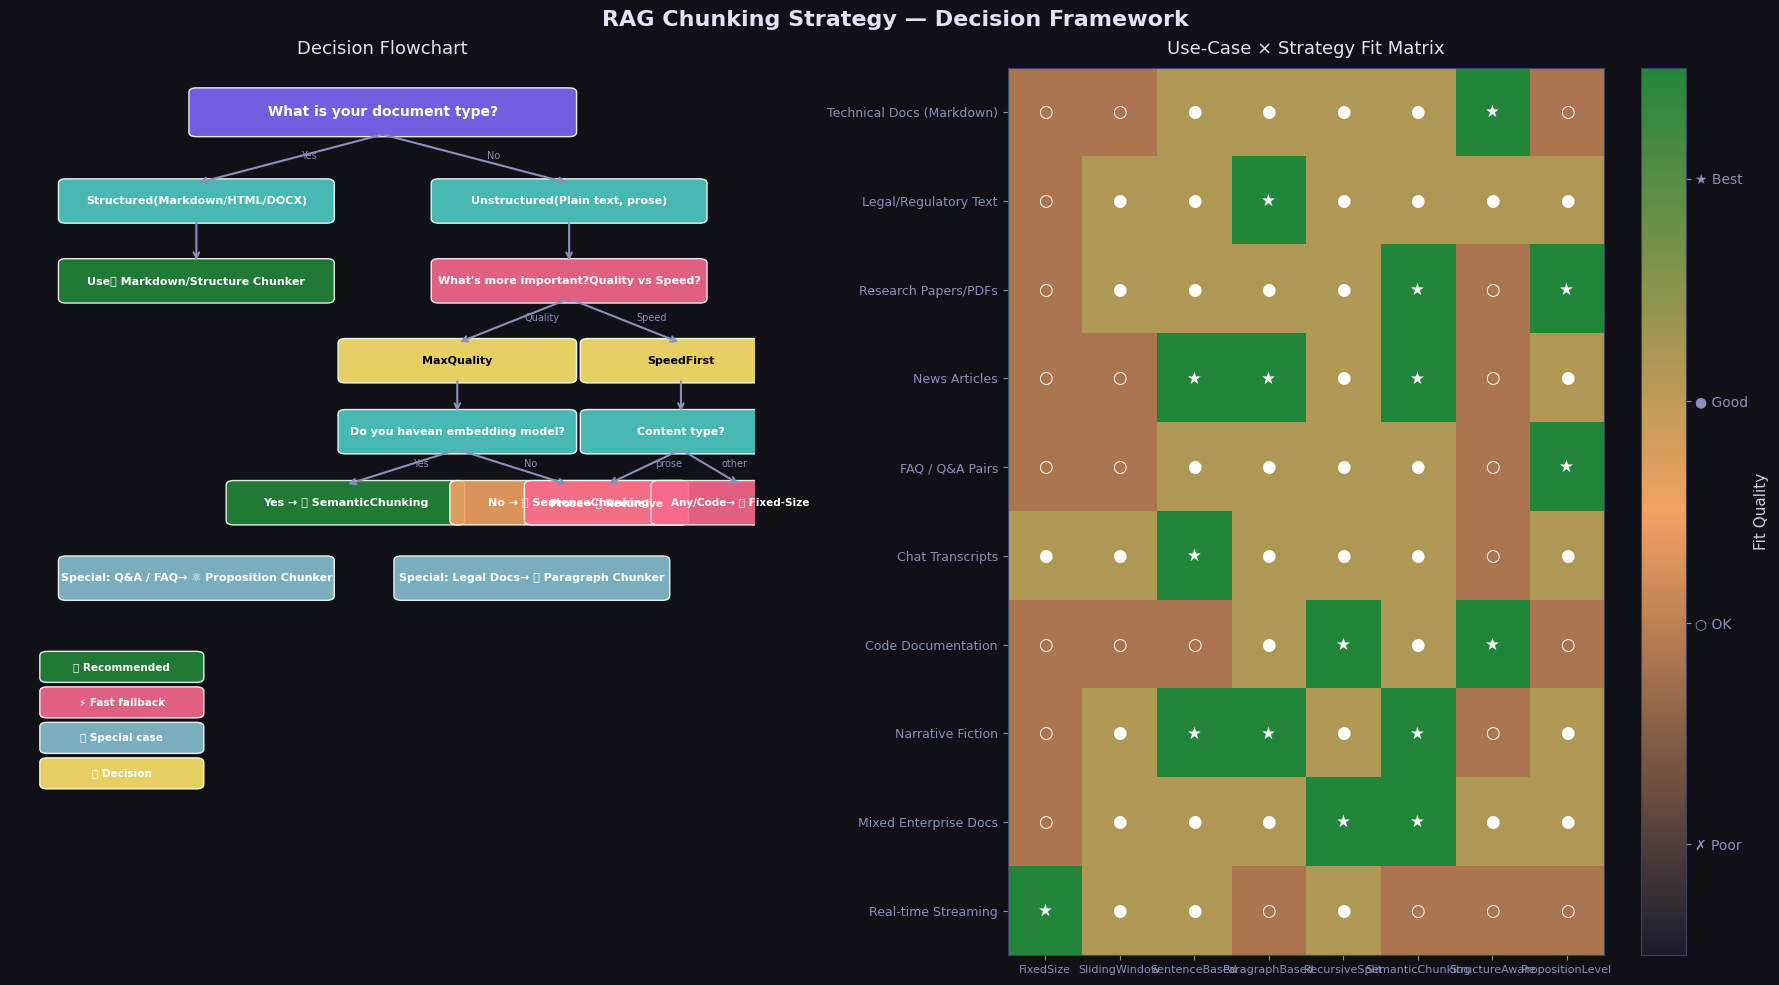

✅ Decision framework rendered


In [26]:
# ─── Decision Framework Visualization ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle("RAG Chunking Strategy — Decision Framework", fontsize=16, fontweight='bold')

# ── Left: Decision tree (text-based flowchart) ────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')
ax.set_title("Decision Flowchart", fontsize=13, pad=10)

def draw_box(ax, x, y, w, h, text, color, fontsize=8.5, text_color='white'):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor='white', linewidth=1, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=text_color, fontweight='bold', wrap=True,
            multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#8890bb'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.15, my, label, fontsize=7, color=color)

# Start
draw_box(ax, 5, 19, 5, 0.9, "What is your document type?", '#7c6af7', 10)

# Level 1: Structured vs Unstructured
draw_box(ax, 2.5, 17, 3.5, 0.8, "Structured(Markdown/HTML/DOCX)", '#4ecdc4', 8)
draw_box(ax, 7.5, 17, 3.5, 0.8, "Unstructured(Plain text, prose)", '#4ecdc4', 8)
draw_arrow(ax, 5, 18.5, 2.5, 17.4, 'Yes')
draw_arrow(ax, 5, 18.5, 7.5, 17.4, 'No')

# Structured branch
draw_box(ax, 2.5, 15.2, 3.5, 0.8, "Use🏗️ Markdown/Structure Chunker", '#22863a', 8)
draw_arrow(ax, 2.5, 16.6, 2.5, 15.6)

# Unstructured branch
draw_box(ax, 7.5, 15.2, 3.5, 0.8, "What's more important?Quality vs Speed?", '#f76a8c', 8)
draw_arrow(ax, 7.5, 16.6, 7.5, 15.6)

# Quality branch
draw_box(ax, 6, 13.4, 3, 0.8, "MaxQuality", '#ffe66d', 8, 'black')
draw_box(ax, 9, 13.4, 2.5, 0.8, "SpeedFirst", '#ffe66d', 8, 'black')
draw_arrow(ax, 7.5, 14.8, 6, 13.8, 'Quality')
draw_arrow(ax, 7.5, 14.8, 9, 13.8, 'Speed')

# Quality sub-branch
draw_box(ax, 6, 11.8, 3, 0.8, "Do you havean embedding model?", '#4ecdc4', 8)
draw_arrow(ax, 6, 13.0, 6, 12.2)

draw_box(ax, 4.5, 10.2, 3, 0.8, "Yes → 🧬 SemanticChunking", '#22863a', 8)
draw_box(ax, 7.5, 10.2, 3, 0.8, "No → 📝 SentenceChunking", '#f4a261', 8)
draw_arrow(ax, 6, 11.4, 4.5, 10.6, 'Yes')
draw_arrow(ax, 6, 11.4, 7.5, 10.6, 'No')

# Speed branch
draw_box(ax, 9, 11.8, 2.5, 0.8, "Content type?", '#4ecdc4', 8)
draw_arrow(ax, 9, 13.0, 9, 12.2)

draw_box(ax, 8, 10.2, 2, 0.8, "Prose→ 🔁 Recursive", '#f76a8c', 7.5)
draw_box(ax, 9.8, 10.2, 2.2, 0.8, "Any/Code→ 📏 Fixed-Size", '#f76a8c', 7.5)
draw_arrow(ax, 9, 11.4, 8, 10.6, 'prose')
draw_arrow(ax, 9, 11.4, 9.8, 10.6, 'other')

# Special cases at bottom
draw_box(ax, 2.5, 8.5, 3.5, 0.8, "Special: Q&A / FAQ→ ⚛️ Proposition Chunker", '#88c0d0', 8)
draw_box(ax, 7, 8.5, 3.5, 0.8, "Special: Legal Docs→ 📄 Paragraph Chunker", '#88c0d0', 8)

# Legend
legend_items = [
    ('#22863a', '✅ Recommended'),
    ('#f76a8c', '⚡ Fast fallback'),
    ('#88c0d0', '🎯 Special case'),
    ('#ffe66d', '🔀 Decision'),
]
for i, (color, label) in enumerate(legend_items):
    y_pos = 6.5 - i * 0.8
    draw_box(ax, 1.5, y_pos, 2, 0.5, label, color, 7.5)


# ── Right: Use-case matrix ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_title("Use-Case × Strategy Fit Matrix", fontsize=13, pad=10)

use_cases = [
    "Technical Docs (Markdown)",
    "Legal/Regulatory Text",
    "Research Papers/PDFs",
    "News Articles",
    "FAQ / Q&A Pairs",
    "Chat Transcripts",
    "Code Documentation",
    "Narrative Fiction",
    "Mixed Enterprise Docs",
    "Real-time Streaming",
]
strategies = [
    "FixedSize",
    "SlidingWindow",
    "SentenceBased",
    "ParagraphBased",
    "RecursiveSplit",
    "SemanticChunking",
    "StructureAware",
    "PropositionLevel",
]

# Fit scores: 0=bad, 1=ok, 2=good, 3=best
fit_matrix = np.array([
    [1, 1, 2, 2, 2, 2, 3, 1],  # Technical Docs
    [1, 2, 2, 3, 2, 2, 2, 2],  # Legal
    [1, 2, 2, 2, 2, 3, 1, 3],  # Research Papers
    [1, 1, 3, 3, 2, 3, 1, 2],  # News Articles
    [1, 1, 2, 2, 2, 2, 1, 3],  # FAQ
    [2, 2, 3, 2, 2, 2, 1, 2],  # Chat
    [1, 1, 1, 2, 3, 2, 3, 1],  # Code Docs
    [1, 2, 3, 3, 2, 3, 1, 2],  # Fiction
    [1, 2, 2, 2, 3, 3, 2, 2],  # Mixed
    [3, 2, 2, 1, 2, 1, 1, 1],  # Real-time
])

cmap_fit = LinearSegmentedColormap.from_list('fit', ['#1a1d2e', '#f4a261', '#22863a'])
im = ax2.imshow(fit_matrix, cmap=cmap_fit, vmin=0, vmax=3, aspect='auto')

ax2.set_xticks(range(len(strategies)))
ax2.set_xticklabels(strategies, fontsize=8)
ax2.set_yticks(range(len(use_cases)))
ax2.set_yticklabels(use_cases, fontsize=9)

labels_map = {0: '✗', 1: '○', 2: '●', 3: '★'}
for i in range(fit_matrix.shape[0]):
    for j in range(fit_matrix.shape[1]):
        val = fit_matrix[i, j]
        ax2.text(j, i, labels_map[val], ha='center', va='center',
                fontsize=12, color='white', fontweight='bold')

plt.colorbar(im, ax=ax2, ticks=[0.375, 1.125, 1.875, 2.625],
             label='Fit Quality').set_ticklabels(['✗ Poor', '○ OK', '● Good', '★ Best'])

plt.tight_layout()
plt.show()
print("✅ Decision framework rendered")


In [27]:
# ─── Printable Decision Guide ─────────────────────────────────────────────────

DECISION_GUIDE = """
╔══════════════════════════════════════════════════════════════════════════════════╗
║              RAG CHUNKING STRATEGY — QUICK REFERENCE GUIDE                     ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                  ║
║  STRATEGY          │ BEST FOR                    │ AVOID WHEN                   ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Fixed-Size        │ Prototyping, homogeneous     │ Prose, legal, high-precision  ║
║                    │ logs, streaming              │ RAG                           ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Sliding Window    │ Dense technical text,        │ Structured Q&A, when storage  ║
║                    │ cross-boundary queries       │ cost matters                  ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Sentence-Based    │ News, FAQ, chatbot data,     │ Code blocks, tables,          ║
║                    │ prose with clear structure   │ mathematical text             ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Paragraph-Based   │ Markdown articles, Wikipedia,│ Very short paragraphs,        ║
║                    │ structured prose             │ unformatted text              ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Recursive Split   │ Mixed content, default       │ When you know exact structure  ║
║                    │ fallback, unknown structure  │ — use specialized method      ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Semantic          │ Research papers, books,      │ Real-time systems, when you    ║
║                    │ transcripts, highest quality │ lack an embedding model        ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Structure-Aware   │ Markdown, HTML, DOCX with    │ Plain text, PDFs without       ║
║  (Markdown/HTML)   │ headers, technical docs      │ structure, scanned documents   ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Proposition       │ Knowledge bases, fact-check  │ Procedural docs, code,        ║
║                    │ systems, high-precision Q&A  │ narrative content              ║
║                                                                                  ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  KEY PARAMETERS                                                                  ║
║  chunk_size  : 256–512 tokens for most cases; 1024 for technical content        ║
║  overlap     : 10–15% of chunk size for prose; 0 for structured content         ║
║  threshold   : Semantic chunking — start at 0.3, tune based on domain           ║
║  min_size    : Filter chunks < 50 chars (fragments add noise to retrieval)      ║
╚══════════════════════════════════════════════════════════════════════════════════╝
"""
print(DECISION_GUIDE)



╔══════════════════════════════════════════════════════════════════════════════════╗
║              RAG CHUNKING STRATEGY — QUICK REFERENCE GUIDE                     ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                  ║
║  STRATEGY          │ BEST FOR                    │ AVOID WHEN                   ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Fixed-Size        │ Prototyping, homogeneous     │ Prose, legal, high-precision  ║
║                    │ logs, streaming              │ RAG                           ║
║  ──────────────────┼─────────────────────────────┼──────────────────────────────║
║  Sliding Window    │ Dense technical text,        │ Structured Q&A, when storage  ║
║                    │ cross-boundary queries       │ cost matters                  ║
║  ──────────────────┼─────────────────────────────┼─────────────

## 12. 🚀 Quick Evaluation Harness <a id='12-harness'></a>

**Plug-and-play wrapper.** Paste your own corpus here and get a full evaluation report in one cell run.

Replace `MY_CORPUS` with your actual text and optionally tune `HARNESS_CONFIG`.


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
#  🚀  RAG CHUNKING EVALUATION HARNESS
#  ─────────────────────────────────────────────────────────────────────────────
#  INSTRUCTIONS:
#    1. Replace MY_CORPUS with your actual text(s)
#    2. Update HARNESS_CONFIG with your constraints
#    3. Run this cell — you'll get a ranked strategy report
# ─────────────────────────────────────────────────────────────────────────────

# ── YOUR CORPUS ──────────────────────────────────────────────────────────────
MY_CORPUS = {
    "your_document": """
    Paste your document text here. The harness will evaluate all chunking strategies
    and recommend the best one for your content. Replace this placeholder with your
    actual content — technical docs, legal text, articles, FAQs, etc.
    
    The harness works best when you provide at least 500 words of representative text
    from your actual use-case corpus.
    """,
    # Add more documents as needed:
    # "document_2": "...",
}

# ── HARNESS CONFIG ────────────────────────────────────────────────────────────
HARNESS_CONFIG = {
    "target_chunk_tokens"  : 512,       # Your embedding model's sweet spot
    "chars_per_token"      : 4,         # ~4 for English
    "max_acceptable_cv"    : 60,        # Max coefficient of variation (%) you tolerate
    "max_storage_overhead" : 30,        # Max % redundant storage you accept
    "has_markdown_headers" : False,     # Set True if your docs have ## headers
    "has_embedding_model"  : False,     # Set True if you can run embeddings
    "latency_sensitive"    : False,     # Set True for real-time / streaming RAG
    "content_type"         : "mixed",   # prose | technical | legal | faq | code | mixed
}

# ─────────────────────────────────────────────────────────────────────────────
# ↓↓↓ DON'T EDIT BELOW THIS LINE — EVALUATION ENGINE ↓↓↓
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_corpus(corpus: Dict[str, str], config: Dict) -> pd.DataFrame:
    """Run all chunkers on corpus and return scored comparison DataFrame."""
    target_chars = config["target_chunk_tokens"] * config["chars_per_token"]
    combined_text = "\n\n".join(corpus.values())
    
    strategies = {
        "Fixed-Size"        : lambda t: fixed_size_chunker(t, target_chars, 0),
        "Fixed+Overlap"     : lambda t: fixed_size_chunker(t, target_chars, target_chars//8),
        "Sliding Window"    : lambda t: sliding_window_chunker(t, target_chars, target_chars//2),
        "Sentence (3)"      : lambda t: sentence_chunker(t, 3, 1),
        "Paragraph"         : lambda t: paragraph_chunker(t, 80, target_chars*2),
        "Recursive"         : lambda t: recursive_chunker(t, target_chars, target_chars//10),
        "Semantic"          : lambda t: semantic_chunker(t, 0.35, 80),
        "Structure-Aware"   : lambda t: markdown_chunker(t, target_chars*2),
        "Proposition"       : lambda t: proposition_chunker(t, 40, target_chars),
    }

    rows = []
    for name, fn in strategies.items():
        try:
            chunks = fn(combined_text)
            if not chunks:
                continue
            sizes = [c["size"] for c in chunks]
            cv    = np.std(sizes) / (np.mean(sizes) + 1e-9) * 100
            overhead = (sum(sizes) / len(combined_text) - 1) * 100
            target_fit = 100 - abs(np.mean(sizes) - target_chars) / target_chars * 100
            
            # ── Heuristic scoring (0–100 per dimension) ──────────────────────
            # 1. Size Uniformity
            uniformity = max(0, 100 - cv)
            
            # 2. Target Fit
            target_fit = max(0, min(100, target_fit))
            
            # 3. Storage Efficiency
            efficiency = max(0, 100 - overhead * 2)
            
            # 4. Semantic Quality proxy
            sem_scores = {
                "Fixed-Size" : 35, "Fixed+Overlap" : 45, "Sliding Window": 55,
                "Sentence (3)": 78, "Paragraph": 82, "Recursive": 70,
                "Semantic": 92, "Structure-Aware": 88, "Proposition": 94,
            }
            sem_quality = sem_scores.get(name, 60)
            
            # 5. Speed score
            speed_scores = {
                "Fixed-Size": 100, "Fixed+Overlap": 99, "Sliding Window": 96,
                "Sentence (3)": 90, "Paragraph": 90, "Recursive": 93,
                "Semantic": 30, "Structure-Aware": 75, "Proposition": 45,
            }
            speed = speed_scores.get(name, 70)
            
            # Config-adjusted weights
            w_sem   = 0.35 if not config["latency_sensitive"] else 0.20
            w_speed = 0.15 if not config["latency_sensitive"] else 0.35
            w_unif  = 0.20
            w_fit   = 0.20
            w_eff   = 0.10
            
            # Penalty: if CV > max or overhead > max
            penalty = 0
            if cv > config["max_acceptable_cv"]:
                penalty += 10
            if overhead > config["max_storage_overhead"]:
                penalty += 10
            if name == "Semantic" and not config["has_embedding_model"]:
                penalty += 20  # can't use without embeddings
            if name == "Structure-Aware" and not config["has_markdown_headers"]:
                penalty += 15
                
            total = (w_sem*sem_quality + w_speed*speed + 
                     w_unif*uniformity + w_fit*target_fit + w_eff*efficiency) - penalty
            total = max(0, min(100, total))

            rows.append({
                "Strategy"        : name,
                "# Chunks"        : len(chunks),
                "Mean Size (chars)": f"{np.mean(sizes):.0f}",
                "CV %"            : f"{cv:.1f}",
                "Storage Overhead%": f"{overhead:.1f}",
                "Sem.Quality"     : sem_quality,
                "Speed"           : speed,
                "TOTAL SCORE"     : round(total, 1),
                "_raw_total"      : total,
            })
        except Exception as e:
            rows.append({"Strategy": name, "# Chunks": "ERROR", 
                         "TOTAL SCORE": 0, "_raw_total": 0,
                         "Mean Size (chars)": "-", "CV %": "-", 
                         "Storage Overhead%": "-", "Sem.Quality": 0, "Speed": 0})

    df_eval = pd.DataFrame(rows).sort_values("_raw_total", ascending=False)
    return df_eval.drop(columns=["_raw_total"])


# ── Run evaluation ────────────────────────────────────────────────────────────
print("🔍 Running RAG Chunking Evaluation Harness...")
print(f"   Corpus: {len(MY_CORPUS)} document(s) | "
      f"{sum(len(t) for t in MY_CORPUS.values()):,} total chars")
print(f"   Target: ~{HARNESS_CONFIG['target_chunk_tokens']} tokens per chunk")
print()

eval_df = evaluate_corpus(MY_CORPUS, HARNESS_CONFIG)

print("=" * 80)
print("  EVALUATION RESULTS (sorted by total score)")
print("=" * 80)
print(eval_df.to_string(index=False))
print("=" * 80)

winner = eval_df.iloc[0]["Strategy"]
runner_up = eval_df.iloc[1]["Strategy"] if len(eval_df) > 1 else "N/A"
print(f"\n  🏆 RECOMMENDED STRATEGY : {winner}")
print(f"  🥈 Runner-up             : {runner_up}")
print(f"\n  Config applied: {HARNESS_CONFIG}")


🔍 Running RAG Chunking Evaluation Harness...
   Corpus: 1 document(s) | 369 total chars
   Target: ~512 tokens per chunk

  EVALUATION RESULTS (sorted by total score)
       Strategy  # Chunks Mean Size (chars) CV % Storage Overhead%  Sem.Quality  Speed  TOTAL SCORE
   Sentence (3)         1               358  0.0              -3.0           78     90         74.9
      Recursive         1               359  0.0              -2.7           70     93         72.5
    Proposition         3               107 16.4             -13.3           94     45         70.1
      Paragraph         2               176 32.6              -4.3           82     90         68.3
 Sliding Window         1               369  0.0               0.0           55     96         67.3
  Fixed+Overlap         1               369  0.0               0.0           45     99         64.2
Structure-Aware         1               359  0.0              -2.7           88     75         61.1
     Fixed-Size         1        

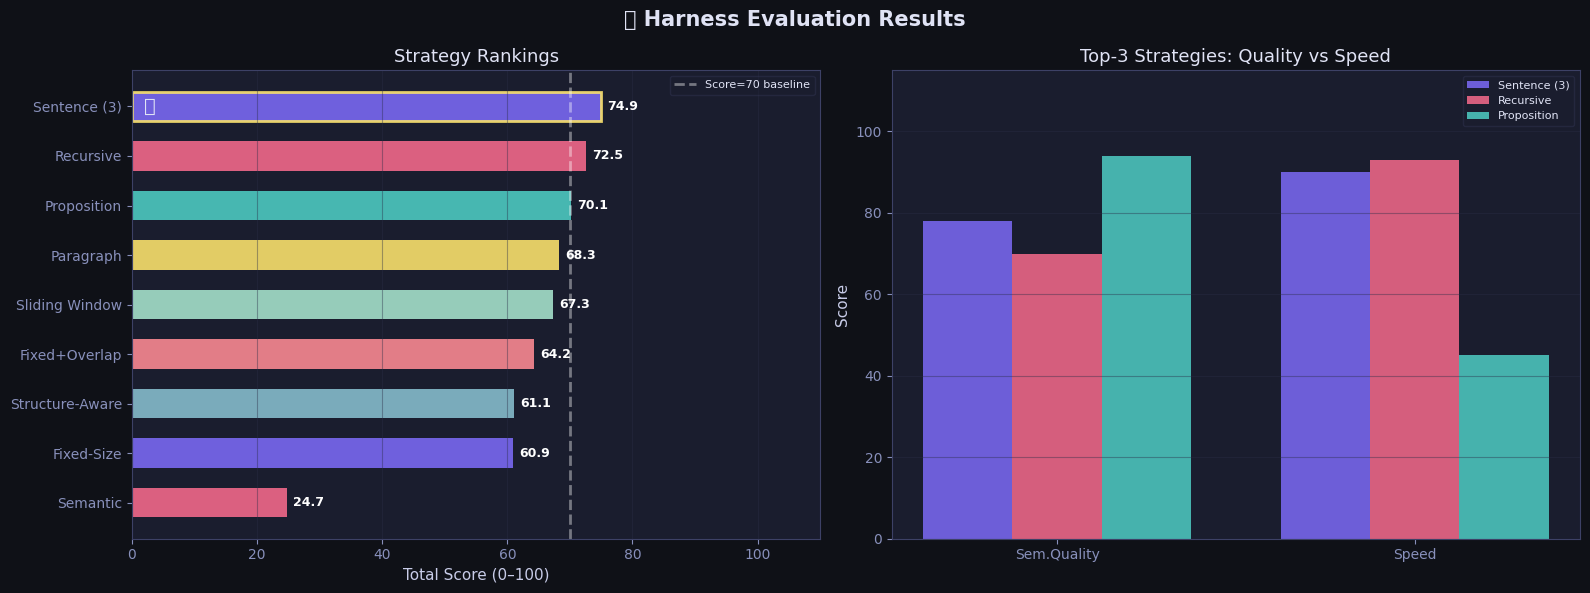


✅ Harness evaluation complete! Replace MY_CORPUS with your own text to re-run.


In [29]:
# ─── Harness Visualization ───────────────────────────────────────────────────

eval_df_plot = eval_df[eval_df["TOTAL SCORE"] > 0].copy()
eval_df_plot["TOTAL SCORE"] = pd.to_numeric(eval_df_plot["TOTAL SCORE"], errors='coerce')
eval_df_plot = eval_df_plot.dropna(subset=["TOTAL SCORE"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("🚀 Harness Evaluation Results", fontsize=15, fontweight='bold')

# Panel 1: Score bar chart
ax = axes[0]
strategies_plot = eval_df_plot["Strategy"].tolist()
scores_plot     = eval_df_plot["TOTAL SCORE"].tolist()
colors_plot     = [ACCENT[0] if i == 0 else ACCENT[i % len(ACCENT)] 
                   for i in range(len(strategies_plot))]

bars = ax.barh(strategies_plot[::-1], scores_plot[::-1], 
               color=colors_plot[::-1], alpha=0.88, height=0.6)
ax.set_xlabel("Total Score (0–100)")
ax.set_title("Strategy Rankings")
ax.set_xlim(0, 110)

for bar, val in zip(bars, scores_plot[::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}',
            va='center', fontsize=9, color='white', fontweight='bold')

ax.axvline(x=70, color='white', linestyle='--', alpha=0.4, label='Score=70 baseline')
ax.legend(fontsize=8)
ax.grid(True, axis='x', alpha=0.4)

# Highlight winner
bars[-1].set_edgecolor('#ffe66d')
bars[-1].set_linewidth(2)
ax.text(2, len(strategies_plot)-1, '🏆', fontsize=14, va='center')

# Panel 2: Multi-dim radar using bar chart
ax2 = axes[1]
dims    = ['Sem.Quality', 'Speed']
numeric_eval = eval_df_plot.copy()
for col in dims:
    numeric_eval[col] = pd.to_numeric(numeric_eval[col], errors='coerce')

top3 = numeric_eval.head(3)
x = np.arange(len(dims))
width = 0.25

for i, (_, row) in enumerate(top3.iterrows()):
    vals = [row[d] for d in dims]
    ax2.bar(x + i*width, vals, width, alpha=0.85, color=ACCENT[i],
            label=row["Strategy"])

ax2.set_xticks(x + width)
ax2.set_xticklabels(dims)
ax2.set_ylabel("Score")
ax2.set_title("Top-3 Strategies: Quality vs Speed")
ax2.legend(fontsize=8)
ax2.set_ylim(0, 115)
ax2.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.show()
print("\n✅ Harness evaluation complete! Replace MY_CORPUS with your own text to re-run.")


## Summary & Next Steps

### What you've learned
- **Fixed-size** is fast but semantically blind — avoid for production RAG.
- **Sliding window** adds context continuity at the cost of storage redundancy.
- **Sentence-based** respects natural language units — great for most prose.
- **Paragraph-based** is highest coherence when documents are well-structured.
- **Recursive splitting** is the best general-purpose default when structure is unknown.
- **Semantic chunking** achieves the highest retrieval quality but requires embeddings.
- **Structure-aware (Markdown)** is optimal for technical documentation and wikis.
- **Proposition-level** maximizes precision for knowledge bases and fact-heavy Q&A.

### Production Checklist
- [ ] Run Section 12 harness on your actual corpus  
- [ ] Replace TF-IDF in semantic chunker with your embedding model  
- [ ] Evaluate retrieval recall@k on a labeled query set  
- [ ] Tune `chunk_size` to your embedding model's token limit  
- [ ] Filter chunks shorter than ~50 tokens (noise)  
- [ ] Add chunk metadata (source, section, page) for filtered retrieval  
- [ ] Re-run harness when you switch embedding models or add new doc types  

---
*Notebook generated for RAG project evaluation. Maintain alongside your retrieval pipeline.*
